In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("../data/terremoti_ingv_1985_2025_extended.csv")

In [3]:
data

,time,magnitude,place,depth,latitude,longitude,year,month,day,hour,...,season,decade,province_code,province_name,region,region_density,area,power,mag_z,depth_z
0,1985-01-02 22:57:43.090,2.6,6 km S Civitella Alfedena (AQ),5.8,41.7150,13.9410,1985,1,2,22,...,winter,1985–1994,AQ,L'Aquila,Abruzzo,4.125473,Sud,mid-low,1.659074,-0.350789
1,1985-01-03 00:46:16.990,2.5,6 km NE Picinisco (FR),6.1,41.6770,13.9310,1985,1,3,0,...,winter,1985–1994,FR,Frosinone,Lazio,2.473480,Centro,mid-low,1.506194,-0.334980
2,1985-01-05 08:32:41.900,2.6,3 km NW Fiastra (MC),2.8,43.0560,13.1390,1985,1,5,8,...,winter,1985–1994,MC,Macerata,Marche,10.147873,Centro,mid-low,1.659074,-0.508877
3,1985-01-05 10:13:26.800,2.2,1 km E San Raffaele Cimena (TO),20.8,45.1500,7.8600,1985,1,5,10,...,winter,1985–1994,TO,Torino,Piemonte,0.236617,Nord,mid-low,1.047554,0.439648
4,1985-01-06 03:52:23.380,2.4,3 km W Gubbio (PG),10.0,43.3570,12.5370,1985,1,6,3,...,winter,1985–1994,PG,Perugia,Umbria,12.044660,Centro,mid-low,1.353314,-0.129467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441817,2024-12-31 22:00:34.100000,1.2,5 km NE Barberino di Mugello (FI),10.2,44.0287,11.2822,2024,12,31,22,...,winter,2015–2024,FI,Firenze,Toscana,0.869491,Centro,low,-0.481247,-0.118928
441818,2024-12-31 22:51:12.920000,1.1,4 km NE Barberino di Mugello (FI),10.3,44.0262,11.2815,2024,12,31,22,...,winter,2015–2024,FI,Firenze,Toscana,0.869491,Centro,low,-0.634127,-0.113658
441819,2024-12-31 23:29:28.530000,1.0,5 km NE Barberino di Mugello (FI),9.1,44.0267,11.2852,2024,12,31,23,...,winter,2015–2024,FI,Firenze,Toscana,0.869491,Centro,low,-0.787007,-0.176893
441820,2024-12-31 23:39:56.600000,0.7,4 km NE Barberino di Mugello (FI),10.1,44.0273,11.2777,2024,12,31,23,...,winter,2015–2024,FI,Firenze,Toscana,0.869491,Centro,low,-1.245647,-0.124197


## Analisi Temporale

#### Trend Storico (1985-2025)

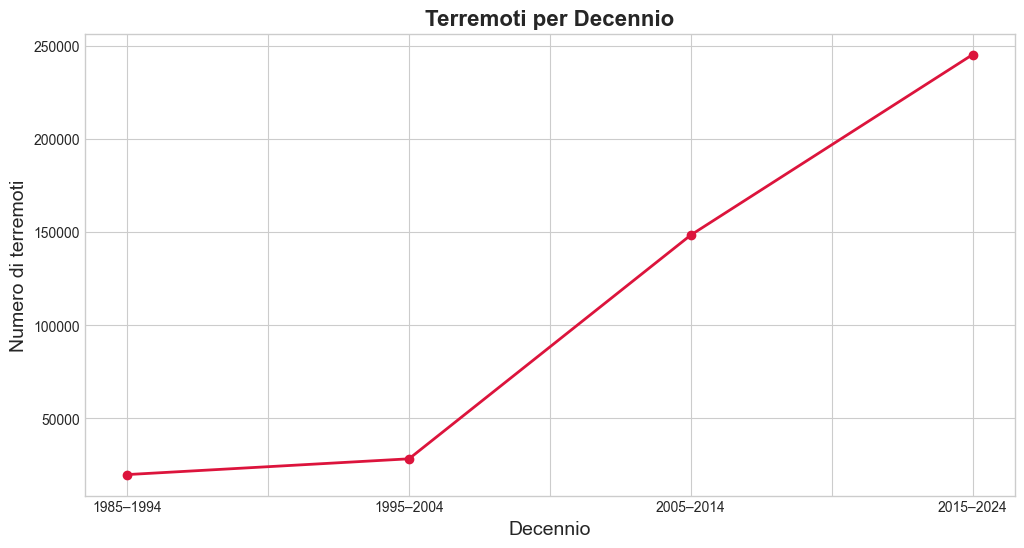

In [4]:
# Imposta lo stile grafico di matplotlib con il tema "seaborn" versione 0.8 con griglia bianca
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una nuova figura con dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette colori di seaborn su "muted" per colori smorzati e gradevoli
sns.set_palette("muted")

# Conta il numero di terremoti per ogni decennio e ordina i risultati per decade (indice)
counts = data['decade'].value_counts().sort_index()

# Disegna un grafico a linee con punti marcati, linea rossa cremisi e spessore 2
counts.plot(kind='line', marker='o', color='crimson', linewidth=2)

# Titolo del grafico con font grande e in grassetto
plt.title('Terremoti per Decennio', fontsize=16, fontweight='bold')

# Etichetta asse dell'ascissa
plt.xlabel('Decennio', fontsize=14)

# Etichetta asse delle ordinate
plt.ylabel('Numero di terremoti', fontsize=14)

# Imposta le etichette dell'asse x senza rotazione per miglior leggibilità
plt.xticks(rotation=0)

# Salva la figura su file PNG ad alta risoluzione (300 dpi) con margini stretti
plt.savefig('../images/terremoti_per_decennio.png', dpi=300, bbox_inches='tight')

# Mostra il grafico a video
plt.show()

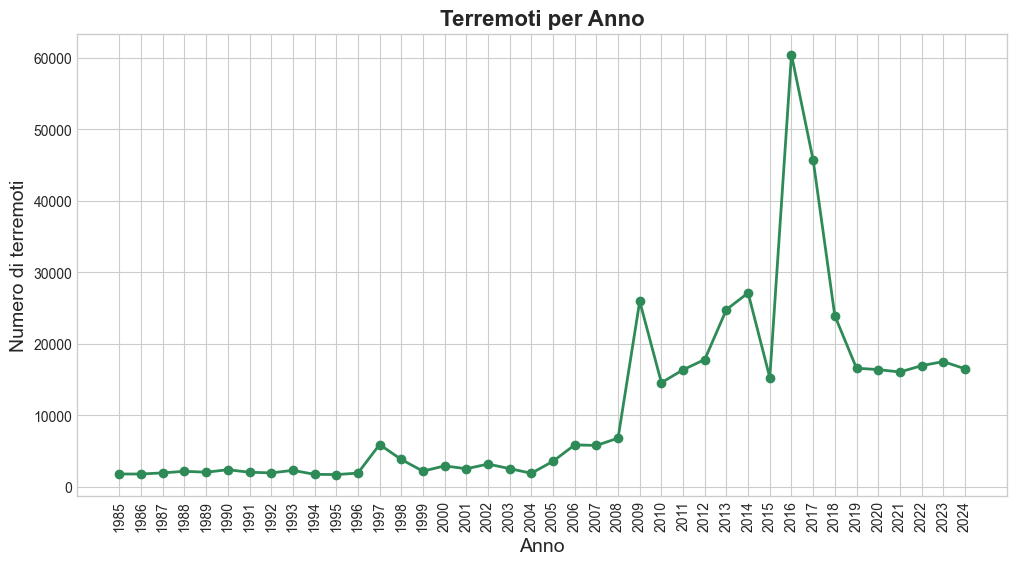

In [5]:
# Imposta lo stile grafico di matplotlib con tema seaborn versione 0.8 con griglia bianca
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una nuova figura con dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette colori di seaborn su "muted" per colori smorzati e armoniosi
sns.set_palette("muted")

# Conta il numero di terremoti per ogni anno e ordina i risultati in ordine crescente di anno
counts = data['year'].value_counts().sort_index()

# Traccia un grafico a linee con punti marcati, colore verde mare e spessore linea 2
counts.plot(kind='line', marker='o', color='seagreen', linewidth=2)

# Imposta il titolo del grafico con font grande e in grassetto
plt.title('Terremoti per Anno', fontsize=16, fontweight='bold')

# Etichetta dell'asse x
plt.xlabel('Anno', fontsize=14)

# Etichetta dell'asse y
plt.ylabel('Numero di terremoti', fontsize=14)

# Prepara la lista di tutti gli anni presenti nei dati (asse x)
all_years = counts.index.tolist()

# Imposta le etichette dell'asse x usando tutti gli anni, ruotandoli di 90° per leggibilità
plt.xticks(ticks=all_years, labels=[str(y) for y in all_years], rotation=90)

# Salva la figura in formato PNG ad alta risoluzione (300 dpi), con margini ottimizzati
plt.savefig('../images/terremoti_per_anno.png', dpi=300, bbox_inches='tight')

# Mostra il grafico a schermo
plt.show()

In [6]:
annual_counts = data.groupby('year').size()
top_years = annual_counts.nlargest(5)
top_years

year
2016    60479
2017    45702
2014    27113
2009    25941
2013    24780
dtype: int64

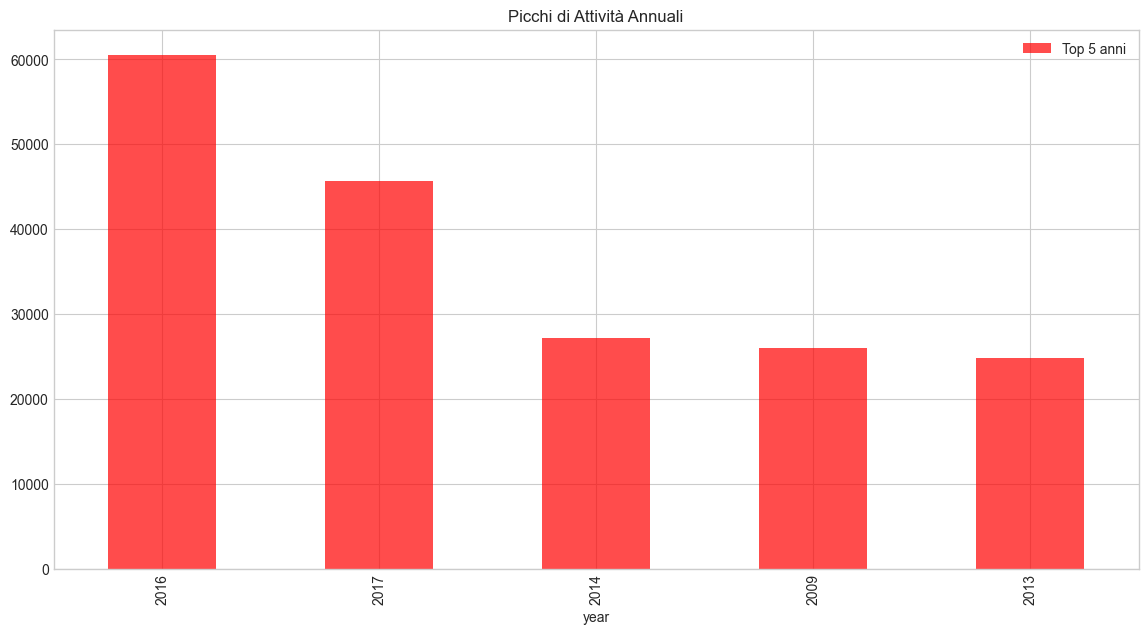

In [7]:
# Crea una nuova figura di dimensioni 14x7 pollici
plt.figure(figsize=(14,7))

# Disegna un grafico a linee grigio con trasparenza 0.5 che mostra il conteggio annuale completo
annual_counts.plot(kind='line', color='grey', alpha=0.5)

# Sovrappone un grafico a barre rosso semi-trasparente (alpha=0.7) per evidenziare i top 5 anni
# Viene usata la selezione annual_counts[top_years.index] per isolare i dati degli anni di picco
annual_counts[top_years.index].plot(
    kind='bar', 
    color='red', 
    alpha=0.7, 
    label='Top 5 anni'
)

# Titolo del grafico
plt.title('Picchi di Attività Annuali')

# Visualizza la legenda per identificare la serie dei "Top 5 anni"
plt.legend()

# Mostra il grafico a schermo
plt.show()

#### Stagionalità

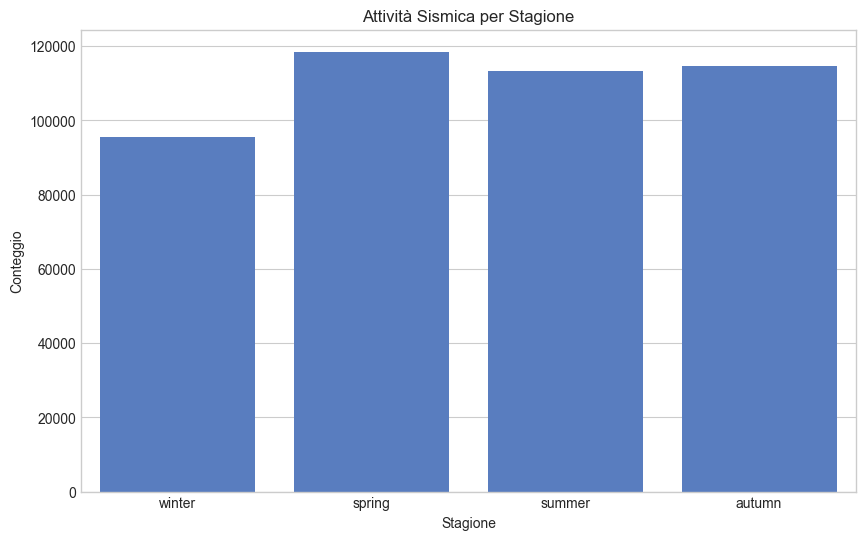

In [8]:
# Crea una nuova figura con dimensioni 10x6 pollici
plt.figure(figsize=(10,6))

# Usa seaborn per disegnare un grafico a barre che conta le occorrenze di ogni stagione
# L'ordine delle stagioni è fissato esplicitamente come inverno, primavera, estate, autunno
sns.countplot(x='season', data=data, order=['winter', 'spring', 'summer', 'autumn'])

# Imposta il titolo del grafico
plt.title('Attività Sismica per Stagione')

# Etichetta dell'asse x
plt.xlabel('Stagione')

# Etichetta dell'asse y
plt.ylabel('Conteggio')

# Mostra il grafico a video
plt.show()

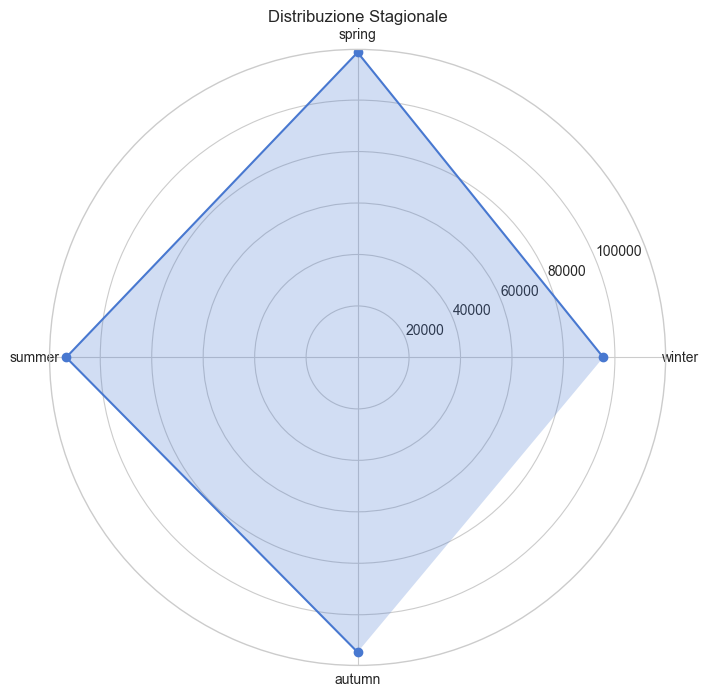

In [9]:
# Definisce l'ordine stagionale da utilizzare (inverno, primavera, estate, autunno)
season_order = ['winter', 'spring', 'summer', 'autumn']

# Conta il numero di eventi per stagione e riordina i risultati secondo season_order
season_counts = data['season'].value_counts().reindex(season_order)

# Crea una nuova figura quadrata 8x8 pollici
plt.figure(figsize=(8,8))

# Crea un subplot polare (grafico circolare a coordinate polari)
ax = plt.subplot(111, polar=True)

# Calcola gli angoli equidistanti per ogni stagione (in radianti), senza duplicare il punto finale
theta = np.linspace(0, 2*np.pi, len(season_order), endpoint=False)

# Traccia la linea che unisce i punti corrispondenti al conteggio per ogni stagione
ax.plot(theta, season_counts.values, marker='o')

# Riempie l'area sotto la curva con trasparenza 0.25 per evidenziare la forma
ax.fill(theta, season_counts.values, alpha=0.25)

# Imposta le etichette angolari (asse x polare) con i nomi delle stagioni
ax.set_xticks(theta)
ax.set_xticklabels(season_counts.index)

# Imposta il titolo del grafico con padding verticale per distanziare dal grafico
plt.title('Distribuzione Stagionale', pad=20)

# Visualizza il grafico a schermo
plt.show()

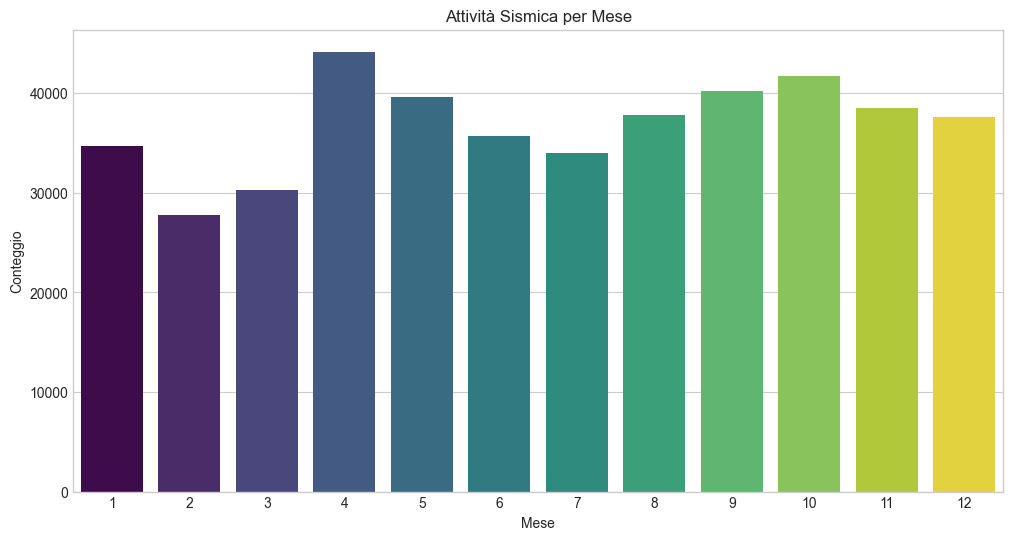

In [10]:
# Crea una nuova figura con dimensioni 12x6 pollici
plt.figure(figsize=(12,6))

# Definisce l'ordine dei mesi da 1 a 12 per visualizzazione ordinata
month_order = [1,2,3,4,5,6,7,8,9,10,11,12]

# Disegna un grafico a barre con seaborn contando i terremoti per mese
# Usa la palette di colori "viridis" per un gradiente piacevole
# Imposta l'ordine dei mesi per evitare che vengano ordinati alfabeticamente
# Il parametro hue='month' colora ogni barra in base al mese (utile con palette)
# Disabilita la legenda perché è ridondante con l'asse x
sns.countplot(x='month', data=data, order=month_order, palette='viridis', hue='month', legend=False)

# Titolo del grafico
plt.title('Attività Sismica per Mese')

# Etichetta asse x
plt.xlabel('Mese')

# Etichetta asse y
plt.ylabel('Conteggio')

# Mostra il grafico a schermo
plt.show()

#### Pattern Giornalieri

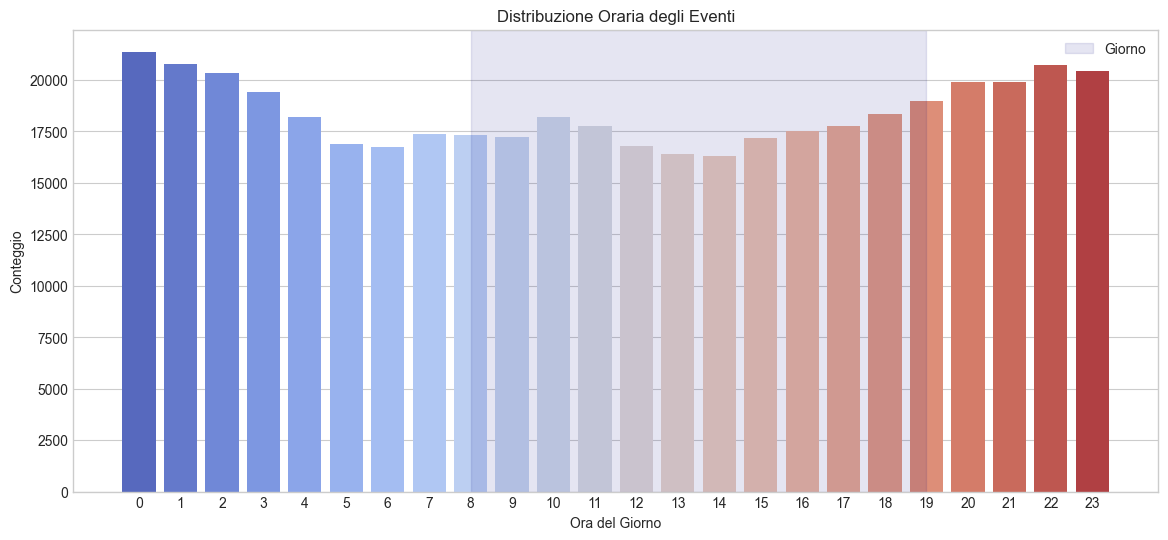

In [11]:
# Crea una nuova figura con dimensioni 14x6 pollici
plt.figure(figsize=(14,6))

# Calcola il numero di eventi per ogni ora del giorno e ordina per ora (0-23)
hourly_counts = data['hour'].value_counts().sort_index()

# Disegna un grafico a barre con seaborn usando i dati ordinati per ora
# La palette 'coolwarm' dà un gradiente di colore da freddo a caldo
# Il parametro hue colora le barre secondo l'ora (convertita in stringa per evitare warning)
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, palette='coolwarm', hue=hourly_counts.index.astype(str))

# Imposta il titolo del grafico
plt.title('Distribuzione Oraria degli Eventi')

# Etichetta asse x (ore del giorno)
plt.xlabel('Ora del Giorno')

# Etichetta asse y (conteggio eventi)
plt.ylabel('Conteggio')

# Evidenzia con un rettangolo semitrasparente l'intervallo orario 8-19 come "Giorno"
plt.axvspan(8, 19, color='navy', alpha=0.1, label='Giorno')

# Mostra la legenda che identifica l'area evidenziata come 'Giorno'
plt.legend()

# Visualizza il grafico a schermo
plt.show()

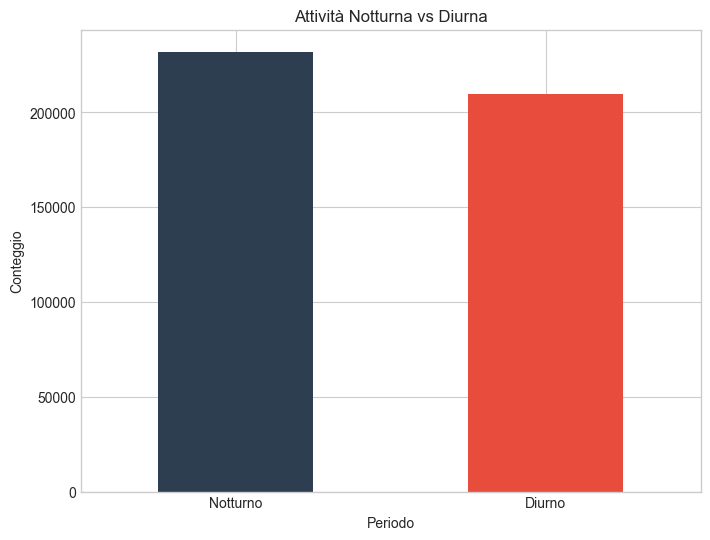

In [12]:
# Crea una nuova figura con dimensioni 8x6 pollici
plt.figure(figsize=(8,6))

# Conta gli eventi per il campo 'period' (diurno o notturno) e crea un grafico a barre
# Usa colori personalizzati: blu scuro per il primo, rosso acceso per il secondo
# rot=0 mantiene le etichette asse x orizzontali (non ruotate)
data['period'].value_counts().plot(
    kind='bar', 
    color=['#2c3e50', '#e74c3c'], 
    rot=0
)

# Imposta il titolo del grafico
plt.title('Attività Notturna vs Diurna')

# Etichetta asse x
plt.xlabel('Periodo')

# Etichetta asse y
plt.ylabel('Conteggio')

# Sostituisce le etichette numeriche (0,1) con le parole 'Notturno' e 'Diurno'
plt.xticks([0,1], ['Notturno', 'Diurno'], rotation=0)

# Mostra il grafico a video
plt.show()

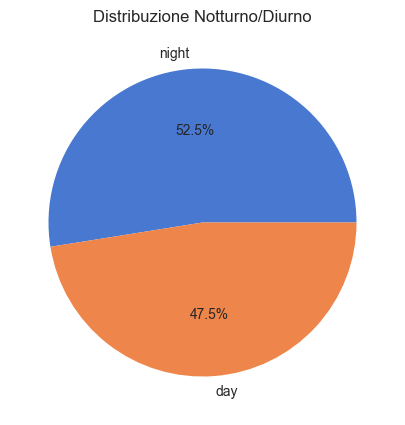

In [13]:
# Crea una nuova figura con dimensioni 8x5 pollici
plt.figure(figsize=(8,5))

# Crea un grafico a torta della distribuzione delle occorrenze di 'period' (notturno/diurno)
# autopct='%1.1f%%' aggiunge le percentuali con una cifra decimale sopra ogni fetta
data['period'].value_counts().plot(kind='pie', autopct='%1.1f%%')

# Imposta il titolo del grafico
plt.title('Distribuzione Notturno/Diurno')

# Rimuove l'etichetta sull'asse y per rendere il grafico più pulito
plt.ylabel('')

# Mostra il grafico a schermo
plt.show()

## Analisi Spaziale

#### Distribuzione Spaziale

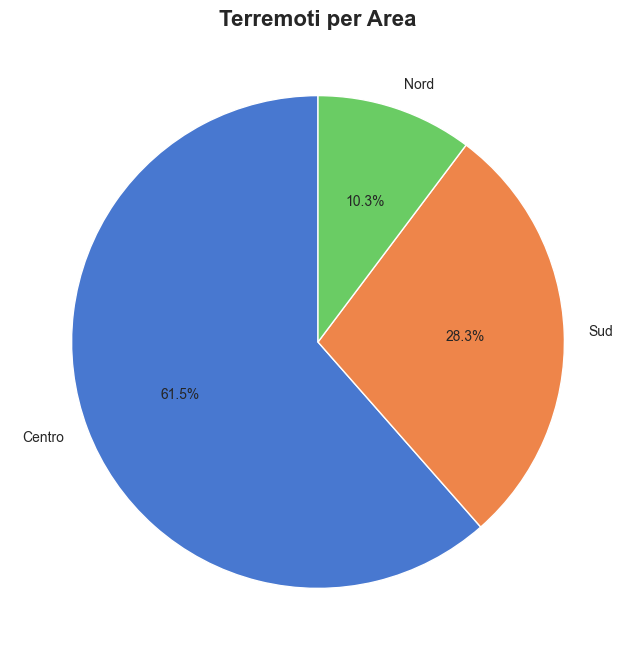

In [14]:
# Imposta lo stile grafico con il tema seaborn 'whitegrid' versione 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una nuova figura quadrata 8x8 pollici
plt.figure(figsize=(8, 8))

# Imposta la palette colori muted di seaborn per un aspetto sobrio e professionale
sns.set_palette("muted")

# Conta gli eventi per ciascuna area geografica e ordina i valori in modo decrescente
data['area'].value_counts().sort_values(ascending=False).plot(
    kind='pie',                       # Grafico a torta
    autopct='%1.1f%%',               # Mostra la percentuale con una cifra decimale su ogni fetta
    colors=sns.color_palette("muted", len(data['area'].unique())),  # Palette colori coerente con il numero di aree
    startangle=90,                   # Ruota il grafico per partire da 90 gradi (in alto)
    wedgeprops={'edgecolor': 'white'}  # Bordo bianco per separare chiaramente le fette
)

# Imposta il titolo con dimensione 16 e grassetto
plt.title('Terremoti per Area', fontsize=16, fontweight='bold')

# Rimuove l'etichetta sull'asse y per un aspetto più pulito
plt.ylabel('')

# Salva l'immagine in alta risoluzione nella cartella images con il nome specificato
plt.savefig('../images/terremoti_per_area.png', dpi=300, bbox_inches='tight')

# Visualizza il grafico a schermo
plt.show()

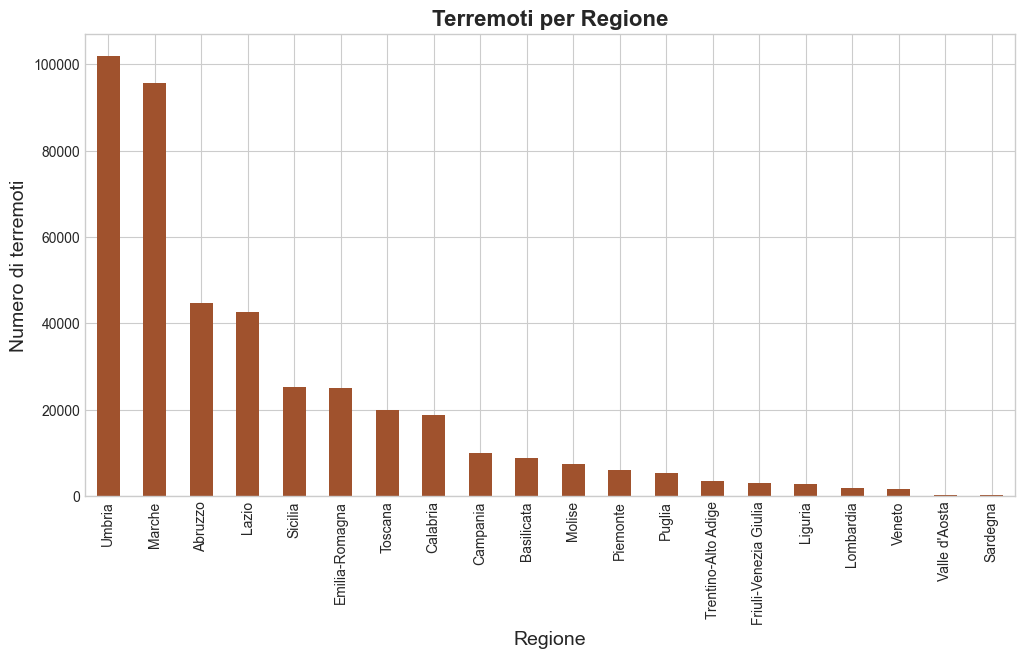

In [15]:
# Imposta lo stile grafico con il tema seaborn 'whitegrid' versione 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una nuova figura con dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette colori muted di seaborn per un aspetto sobrio e professionale
sns.set_palette("muted")

# Conta il numero di terremoti per regione, ordina in ordine decrescente e crea un grafico a barre
data['region'].value_counts().sort_values(ascending=False).plot(kind='bar', color='sienna')

# Imposta il titolo del grafico con dimensione 16 e testo in grassetto
plt.title('Terremoti per Regione', fontsize=16, fontweight='bold')

# Etichetta asse x (regioni) con dimensione font 14
plt.xlabel('Regione', fontsize=14)

# Etichetta asse y (numero di terremoti) con dimensione font 14
plt.ylabel('Numero di terremoti', fontsize=14)

# Ruota le etichette dell'asse x di 90 gradi per migliorarne la leggibilità
plt.xticks(rotation=90)

# Mostra il grafico a schermo
plt.show()

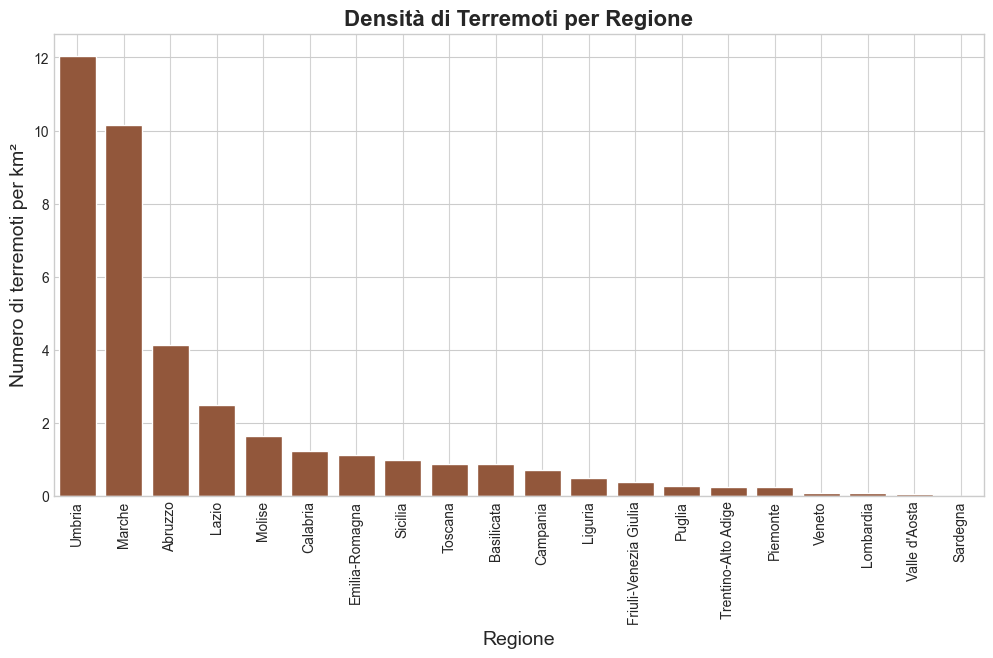

In [16]:
# Imposta lo stile grafico con il tema seaborn 'whitegrid' versione 0.8
plt.style.use('seaborn-v0_8-whitegrid')

# Imposta lo stile seaborn per il grafico con griglia sugli assi
sns.set_style("whitegrid", {'axes.grid': True})

# Imposta la palette colori muted di seaborn per un aspetto sobrio e professionale
sns.set_palette("muted")

# Ordina i dati in base alla densità dei terremoti per regione in ordine decrescente
data_sorted = data.sort_values('region_density', ascending=False)

# Crea una nuova figura con dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Crea un grafico a barre con seaborn usando i dati ordinati per densità
sns.barplot(data=data_sorted, x='region', y='region_density', color='sienna')

# Imposta il titolo del grafico con dimensione 16 e testo in grassetto
plt.title('Densità di Terremoti per Regione', fontsize=16, fontweight='bold')

# Etichetta asse x (regioni) con dimensione font 14
plt.xlabel('Regione', fontsize=14)

# Etichetta asse y (densità terremoti per km²) con dimensione font 14
plt.ylabel('Numero di terremoti per km²', fontsize=14)

# Ruota le etichette dell'asse x di 90 gradi per migliorarne la leggibilità
plt.xticks(rotation=90)

# Aggiunge una griglia leggera verticale (asse x) con linea continua e colore grigio chiaro
plt.grid(True, axis='x', linestyle='-', color='lightgray')

# Salva il grafico in alta risoluzione nella cartella images
plt.savefig('../images/densità_terremoti_per_regione.png', dpi=300, bbox_inches='tight')

# Mostra il grafico a schermo
plt.show()

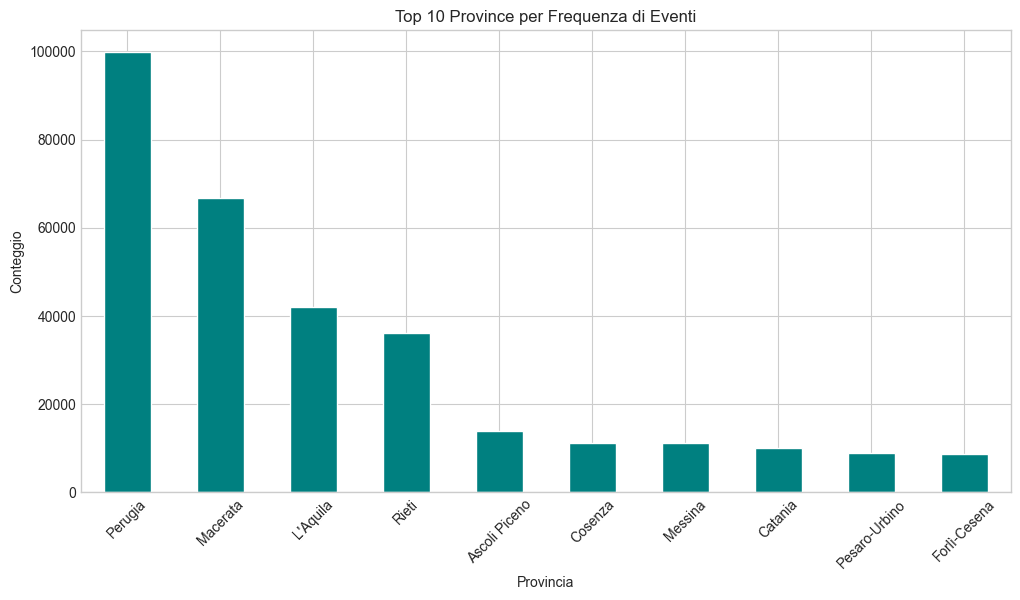

In [17]:
# Estrae le prime 10 province con il maggior numero di eventi sismici
top_places = data['province_name'].value_counts().head(10)

# Crea una nuova figura con dimensioni 12x6 pollici
plt.figure(figsize=(12,6))

# Crea un grafico a barre per le prime 10 province, con barre colorate in teal
top_places.plot(kind='bar', color='teal')

# Imposta il titolo del grafico
plt.title('Top 10 Province per Frequenza di Eventi')

# Etichetta asse x con "Provincia"
plt.xlabel('Provincia')

# Etichetta asse y con "Conteggio"
plt.ylabel('Conteggio')

# Ruota le etichette sull'asse x di 45 gradi per migliore leggibilità
plt.xticks(rotation=45)

# Mostra il grafico a schermo
plt.show()

#### Distribuzione geografica

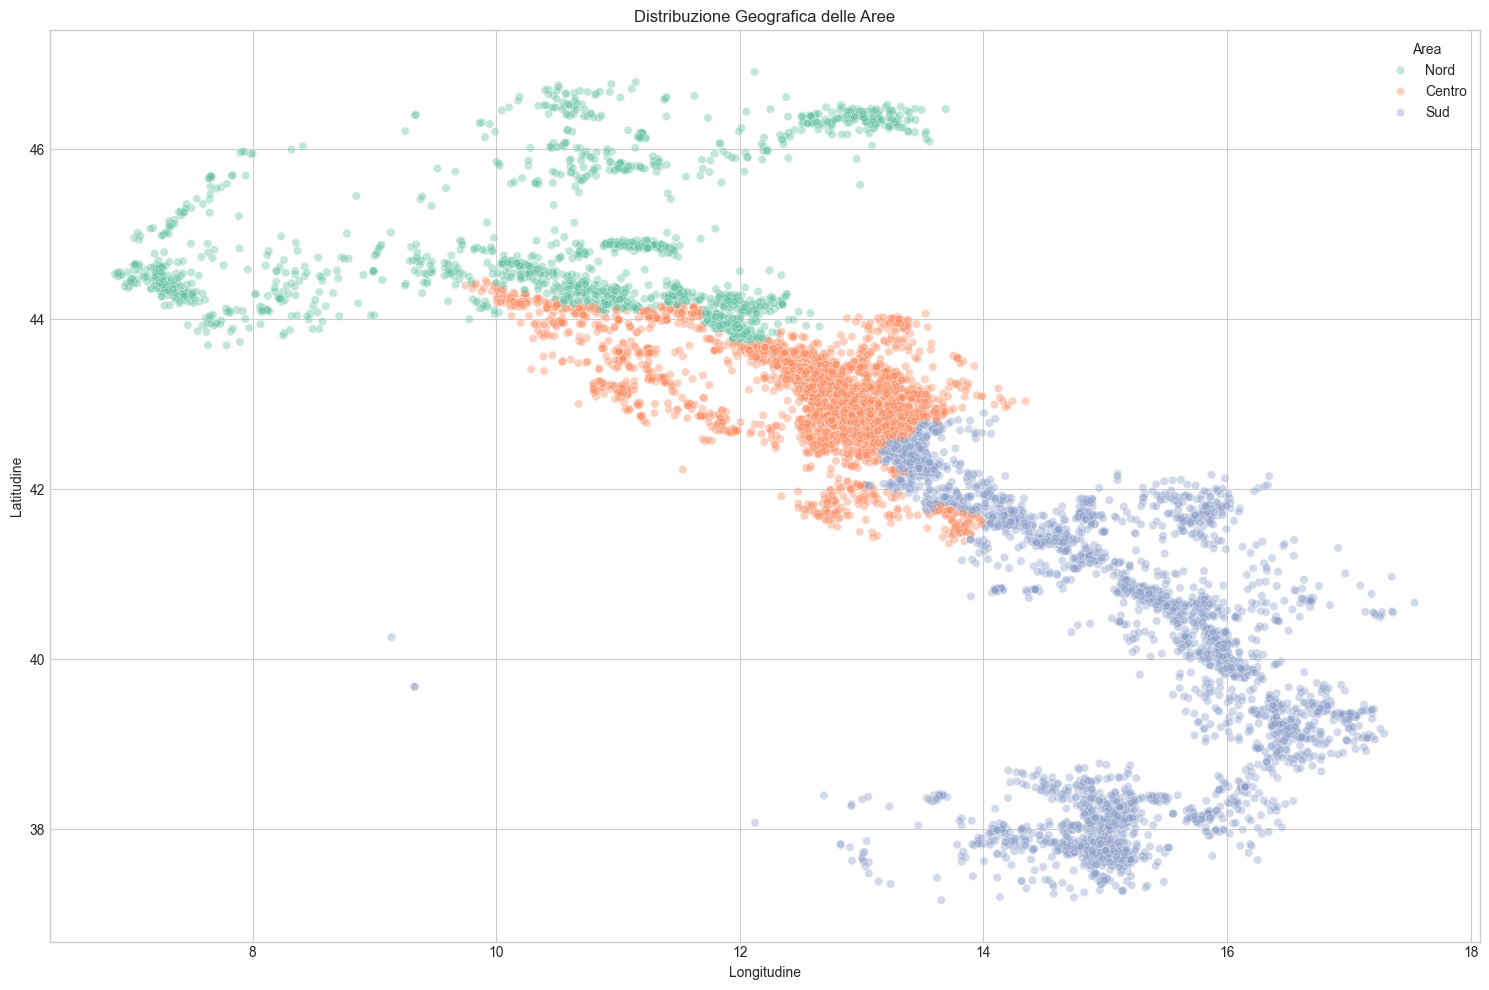

In [18]:
plt.figure(figsize=(15, 10))  # Crea una figura grande 15x10 pollici

sns.scatterplot(
    x='longitude',             # Valori asse x: longitudine
    y='latitude',              # Valori asse y: latitudine
    hue='area',                # Colora i punti in base all'area geografica
    data=data.sample(20000),   # Usa un campione casuale di 20.000 dati per evitare sovraffollamento
    alpha=0.4,                 # Trasparenza dei punti per migliorare la visibilità in caso di sovrapposizioni
    palette='Set2'             # Palette di colori Set2 per distinguere le aree
)

plt.title('Distribuzione Geografica delle Aree')  # Titolo del grafico
plt.xlabel('Longitudine')                          # Etichetta asse x
plt.ylabel('Latitudine')                           # Etichetta asse y
plt.legend(title='Area')                           # Legenda con titolo 'Area'

plt.tight_layout()  # Ottimizza il layout per evitare sovrapposizioni di elementi
plt.show()          # Mostra il grafico

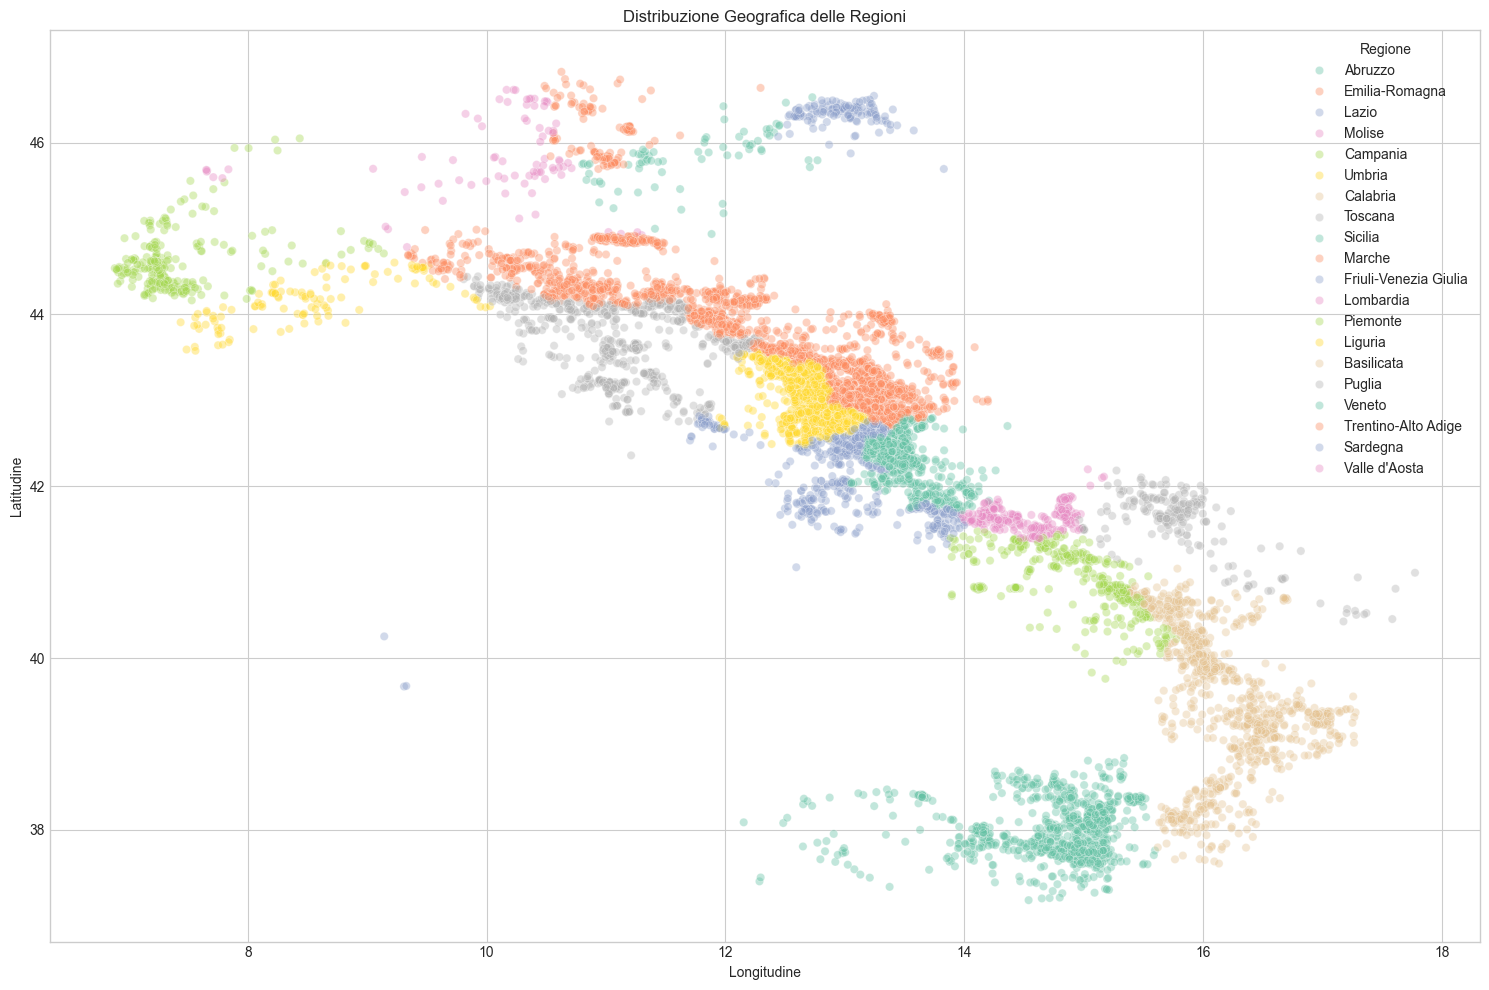

In [19]:
plt.figure(figsize=(15, 10))  # Crea una figura di dimensioni 15x10 pollici

sns.scatterplot(
    x='longitude',              # Asse X: longitudine
    y='latitude',               # Asse Y: latitudine
    hue='region',               # Colora i punti in base alla regione
    data=data.sample(20000),    # Usa un campione casuale di 20.000 punti per evitare sovraffollamento
    alpha=0.4,                  # Trasparenza dei punti per visualizzazione più chiara in caso di sovrapposizioni
    palette='Set2'              # Palette di colori Set2 per distinguere le regioni
)

plt.title('Distribuzione Geografica delle Regioni')  # Titolo del grafico
plt.xlabel('Longitudine')                             # Etichetta asse X
plt.ylabel('Latitudine')                              # Etichetta asse Y
plt.legend(title='Regione')                           # Legenda con titolo 'Regione'

plt.tight_layout()  # Ottimizza il layout per evitare sovrapposizioni
plt.show()          # Mostra il grafico

#### Cluster Spaziali basati sulla Densità

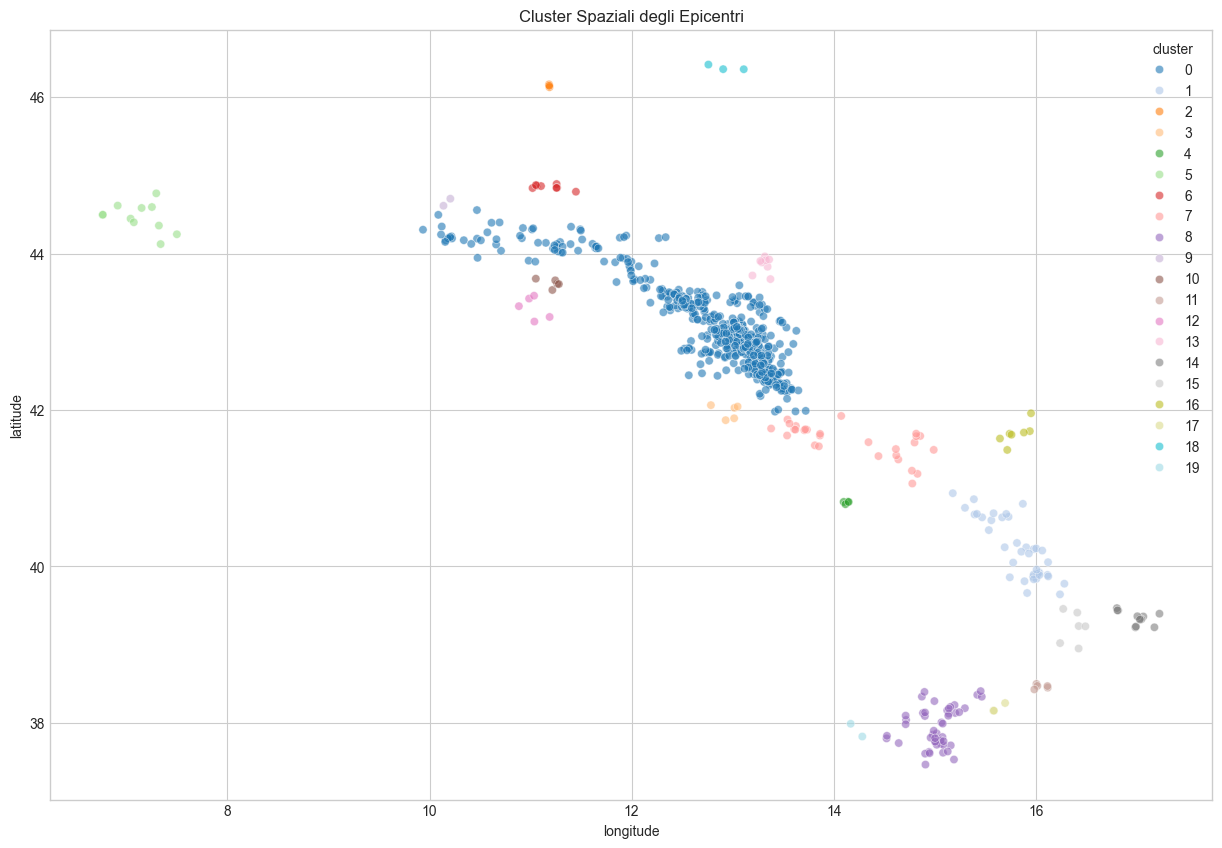

In [20]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Campiona 20.000 dati per la clusterizzazione (per ragioni di performance)
data_samp = data.sample(n=20000, random_state=42)

# Estrae le coordinate (latitudine e longitudine) come array numpy
coords = data_samp[['latitude', 'longitude']].values

# Standardizza le coordinate per dare uguale peso a lat e long nella clusterizzazione
coords_scaled = StandardScaler().fit_transform(coords)

# Applica DBSCAN con eps=0.1 (distanza massima) e min_samples=50 (minimi punti per cluster)
db = DBSCAN(eps=0.1, min_samples=50).fit(coords_scaled)

# Assegna i label dei cluster ai dati campionati (-1 indica rumore/outlier)
data_samp['cluster'] = db.labels_

# Visualizza con scatterplot solo i punti appartenenti ai cluster (escludendo rumore)
plt.figure(figsize=(15,10))
sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='cluster',
    palette='tab20',                  # Palette con 20 colori distinti per i cluster
    data=data_samp[data_samp['cluster'] != -1].sample(1000),  # Campiona 1000 punti per la visualizzazione
    alpha=0.6                        # Trasparenza per migliorare la leggibilità
)
plt.title('Cluster Spaziali degli Epicentri')
plt.show()

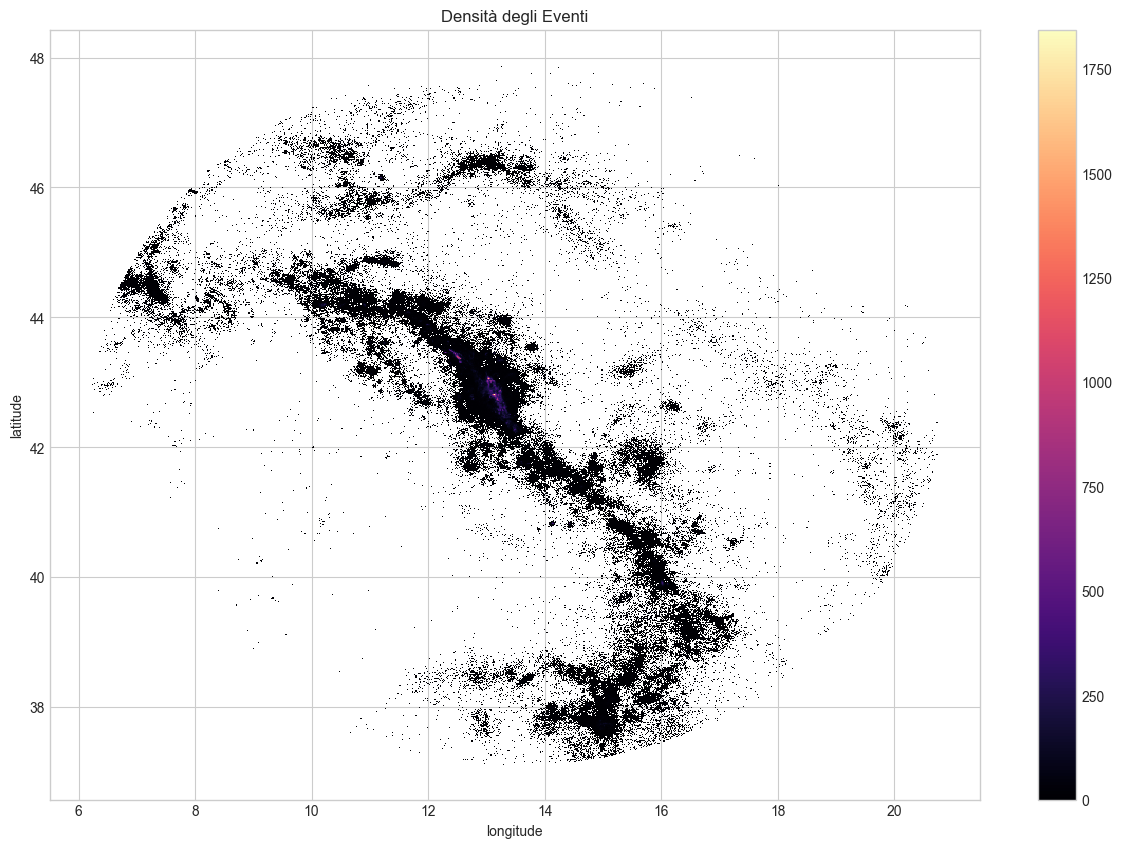

In [21]:
plt.figure(figsize=(15,10))

# Istogramma bidimensionale per visualizzare la densità spaziale degli eventi sismici
sns.histplot(
    x=data['longitude'],  # Coordinata longitudinale
    y=data['latitude'],   # Coordinata latitudinale
    bins=800,             # Numero di bin per asse, elevato per dettaglio fine
    cmap='magma',         # Mappa colori per evidenziare la densità
    cbar=True             # Visualizza la barra colore che indica la densità
)

plt.title('Densità degli Eventi')
plt.show()

#### Mappe geografiche dei terremoti

In [22]:
import folium
from folium.plugins import HeatMap

# Crea una mappa centrata sull'Italia (lat 42.50, lon 12.57) con zoom iniziale 6
m = folium.Map(location=[42.50, 12.57], zoom_start=6)

heat_data = []

# Campiona 15000 eventi dal DataFrame e crea lista per la heatmap: [latitudine, longitudine, magnitudo]
for idx, row in data.sample(15000).iterrows():
    if pd.notnull(row['latitude']) and pd.notnull(row['longitude']) and pd.notnull(row['magnitude']):
        heat_data.append([row['latitude'], row['longitude'], row['magnitude']])

# Aggiunge la heatmap dei terremoti con intensità proporzionale alla magnitudo e raggio 15
HeatMap(heat_data, radius=15).add_to(m)

# Salva la mappa in un file HTML
# m.save('../maps/heatmap.html')

In [23]:
# Seleziona le coordinate (prima occorrenza) delle province più frequenti negli eventi
top_coords = data[data['province_name'].isin(top_places.index)].groupby('province_name').first()

# Crea mappa centrata sull'Italia
m = folium.Map(location=[42.50, 12.57], zoom_start=6)

# Aggiunge un marker rosso per ciascuna provincia top con popup che mostra il nome e il numero di eventi
for province, row in top_coords.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"{province}<br>Eventi: {top_places[province]}",
        icon=folium.Icon(color='red')
    ).add_to(m)

# Salva la mappa in HTML
# m.save('../maps/top_places_map.html')

In [24]:
# Seleziona i terremoti outlier con z-score > 3 per magnitudo o profondità
outliers = data[(np.abs(data['mag_z']) > 3) | (np.abs(data['depth_z']) > 3)]

# Crea una mappa centrata sull'Italia
m = folium.Map(location=[42.50, 12.57], zoom_start=6)

# Aggiunge marker circolari per ogni outlier
# Il raggio del marker è proporzionale alla magnitudo
# I marker sono rossi se l'outlier è sulla magnitudo, blu altrimenti (profondità)
for idx, row in outliers.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['magnitude'],
        popup=f"{row['time']}<br>Mag: {row['magnitude']}<br>Depth: {row['depth']}",
        color='red' if row['mag_z'] > 3 else 'blue'
    ).add_to(m)

# Salva la mappa in HTML
# m.save('../maps/anomalies.html')

In [25]:
# Dizionario con i principali eventi sismici storici e le loro coordinate
places = {
    'Valle del Belice (1968)': [37.68, 12.82],
    'Friuli Venezia Giulia (1976)': [46.27, 13.13],
    'Irpinia (1980)': [40.85, 15.30],
    'Marche-Umbria (1997)': [43.00, 12.88],
    'Molise-Puglia (2002)': [41.72, 14.96],
    'Abruzzo (2009)': [42.35, 13.38],
    'Emilia Romagna (2012)': [44.89, 11.23],
    'Centro Italia (2016)': [42.70, 13.23],
}

# Crea una mappa centrata sull'Italia
m = folium.Map(location=[42.50, 12.57], zoom_start=6)

# Aggiunge un marker per ogni evento storico con popup col nome
for name, coords in places.items():
    folium.Marker(
        location=coords,
        popup=name,
        icon=folium.Icon(color='red')
    ).add_to(m)

# Salva la mappa in un file HTML
m.save('../map/top_earthquakes.html')

## Analisi di magnitudo e profondità

#### Distribuzione della Magnitudo

In [26]:
print(data['magnitude'].describe())

count    441822.000000
mean          1.514787
std           0.654107
min           0.000000
25%           1.000000
50%           1.400000
75%           1.900000
max           6.500000
Name: magnitude, dtype: float64


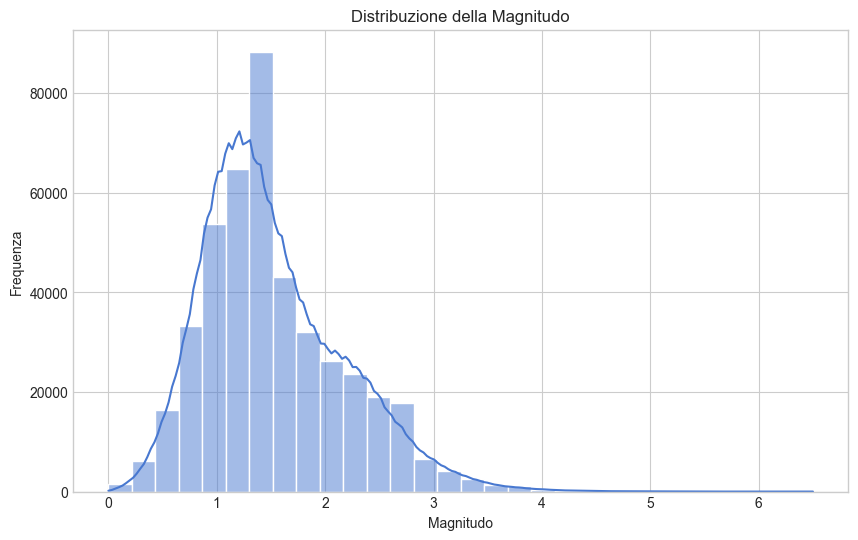

In [27]:
# Imposta la dimensione della figura (larghezza=10 pollici, altezza=6 pollici)
plt.figure(figsize=(10,6))

# Crea un istogramma della colonna 'magnitude' del DataFrame 'data' con 30 bin
# La linea 'kde=True' aggiunge una stima della densità di probabilità (curva liscia)
sns.histplot(data['magnitude'], bins=30, kde=True)

# Imposta il titolo del grafico
plt.title('Distribuzione della Magnitudo')

# Etichetta l'asse X
plt.xlabel('Magnitudo')

# Etichetta l'asse Y
plt.ylabel('Frequenza')

# Mostra il grafico a schermo
plt.show()

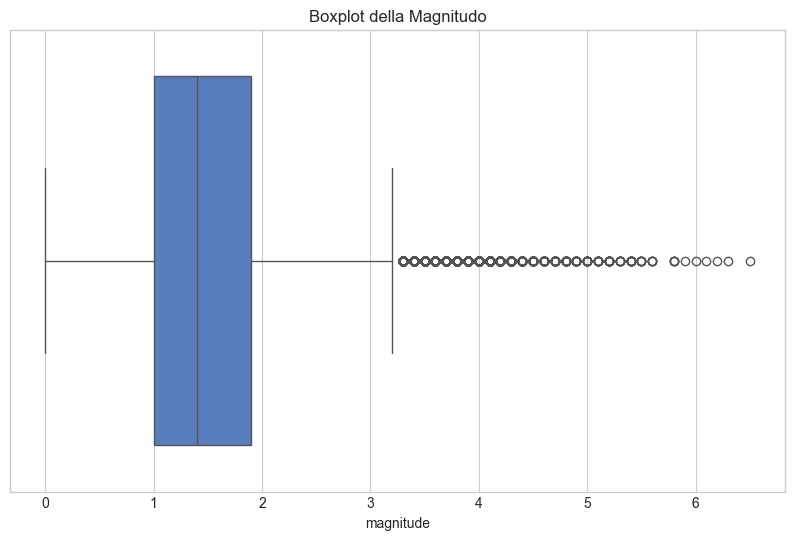

In [28]:
# Imposta la dimensione della figura (larghezza=10 pollici, altezza=6 pollici)
plt.figure(figsize=(10,6))

# Crea un boxplot per la colonna 'magnitude' del DataFrame 'data'
sns.boxplot(x=data['magnitude'])

# Imposta il titolo del grafico
plt.title('Boxplot della Magnitudo')

# Mostra il grafico a schermo
plt.show()

In [29]:
top_magnitudes = data.nlargest(10, 'magnitude')[['time', 'magnitude', 'place']]
top_magnitudes

,time,magnitude,place
245245,2016-10-30 06:40:17.320,6.5,4 km NE Norcia (PG)
374759,2020-12-29 11:19:54.080000,6.3,Croatia [Land]
356920,2019-11-26 02:54:11.280000,6.2,Costa Albanese settentrionale (ALBANIA)
71826,2009-04-06 01:32:40.400,6.1,2 km SW L'Aquila (AQ)
219813,2016-08-24 01:36:32.000,6.0,1 km W Accumoli (RI)
242053,2016-10-26 19:18:07.420,5.9,3 km S Visso (MC)
25373,1997-09-26 09:40:24.950,5.8,6 km SW Serravalle di Chienti (MC)
56681,2006-10-26 14:28:36.580,5.8,Tirreno Meridionale (MARE)
131089,2012-05-20 02:03:50.170,5.8,7 km NW Finale Emilia (MO)
244148,2016-10-28 20:02:43.150,5.8,Tirreno Meridionale (MARE)


#### Profondità media e relazione con la Magnitudo

In [30]:
print("Profondità media:", data['depth'].mean())
print("Mediana profondità:", data['depth'].median())

Profondità media: 12.456870187541586
Mediana profondità: 10.0


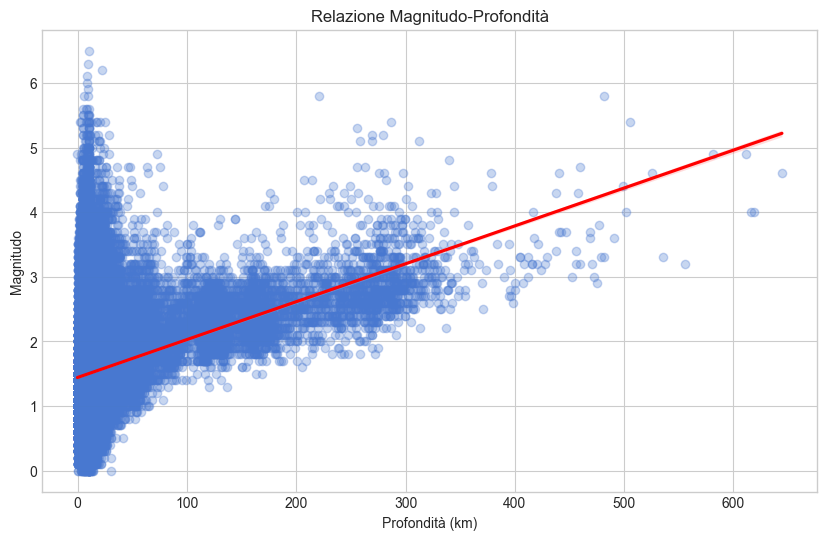

In [31]:
# Imposta la dimensione della figura (larghezza=10 pollici, altezza=6 pollici)
plt.figure(figsize=(10,6))

# Crea un grafico di regressione tra 'depth' (profondità) e 'magnitude' (magnitudo)
# scatter_kws: opacità dei punti dati impostata a 0.3 per maggiore trasparenza
# line_kws: colore della linea di regressione impostato a rosso
sns.regplot(x='depth', y='magnitude', data=data, 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

# Imposta il titolo del grafico
plt.title('Relazione Magnitudo-Profondità')

# Etichetta l'asse X
plt.xlabel('Profondità (km)')

# Etichetta l'asse Y
plt.ylabel('Magnitudo')

# Attiva la griglia per facilitare la lettura del grafico
plt.grid(True)

# Mostra il grafico a schermo
plt.show()

In [32]:
print(f"\nCorrelazione Pearson: {data['depth'].corr(data['magnitude']):.4f}")


Correlazione Pearson: 0.1701


In [33]:
print("\nMagnitudo media per intervalli di profondità:")

# Suddivide la colonna 'depth' in 5 intervalli (bin)
bins = pd.cut(data['depth'], bins=5)

# Raggruppa i dati per questi intervalli di profondità e calcola la magnitudo media per ciascun intervallo
# observed=False considera tutte le categorie anche se non presenti
print(data.groupby(bins, observed=False)['magnitude'].mean())


Magnitudo media per intervalli di profondità:
depth
(-0.945, 128.64]    1.507315
(128.64, 257.58]    2.440457
(257.58, 386.52]    2.975180
(386.52, 515.46]    3.481633
(515.46, 644.4]     4.187500
Name: magnitude, dtype: float64


#### Distribuzione della potenza

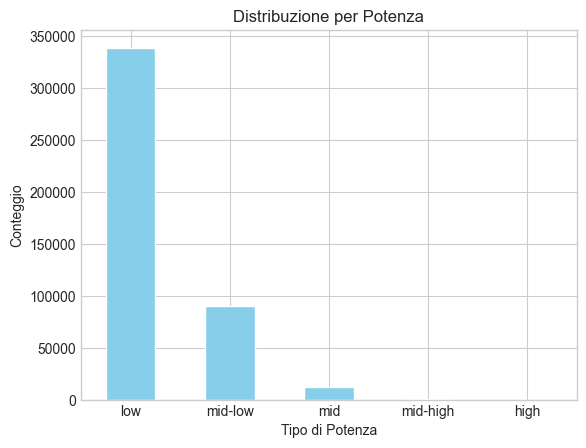

In [34]:
# Conta la frequenza di ogni categoria presente nella colonna 'power'
# e ne crea un grafico a barre con colore azzurro chiaro
data['power'].value_counts().plot(kind='bar', color='skyblue')

# Imposta il titolo del grafico
plt.title('Distribuzione per Potenza')

# Etichetta l'asse x
plt.xlabel('Tipo di Potenza')

# Etichetta l'asse y
plt.ylabel('Conteggio')

# Imposta le etichette delle barre senza rotazione (orizzontali)
plt.xticks(rotation=0)

# Visualizza il grafico
plt.show()

## Analisi spazio-temporale di magnitudo e profondità

#### Analisi spaziale di magnitudo e profondità

In [35]:
# Raggruppa i dati per colonna 'area' e calcola statistiche aggregate su magnitudo, profondità e conteggio eventi
area_stats = data.groupby('area', observed=True).agg({
    'magnitude': ['mean', 'max'],   # media e massimo della magnitudo per area
    'depth': ['mean', 'median'],    # media e mediana della profondità per area
    'time': 'count'                 # conteggio degli eventi (basato sulla colonna 'time') per area
}).sort_values(('time', 'count'), ascending=False)  # ordina i risultati per numero di eventi, decrescente

print("Confronto per area:")
print(area_stats)

Confronto per area:
       magnitude           depth           time
            mean  max       mean median   count
area                                           
Centro  1.344193  6.5  10.038344    9.9  260220
Sud     1.666159  6.1  14.176786   10.0  119602
Nord    1.755688  5.8  11.616737    9.9   43431


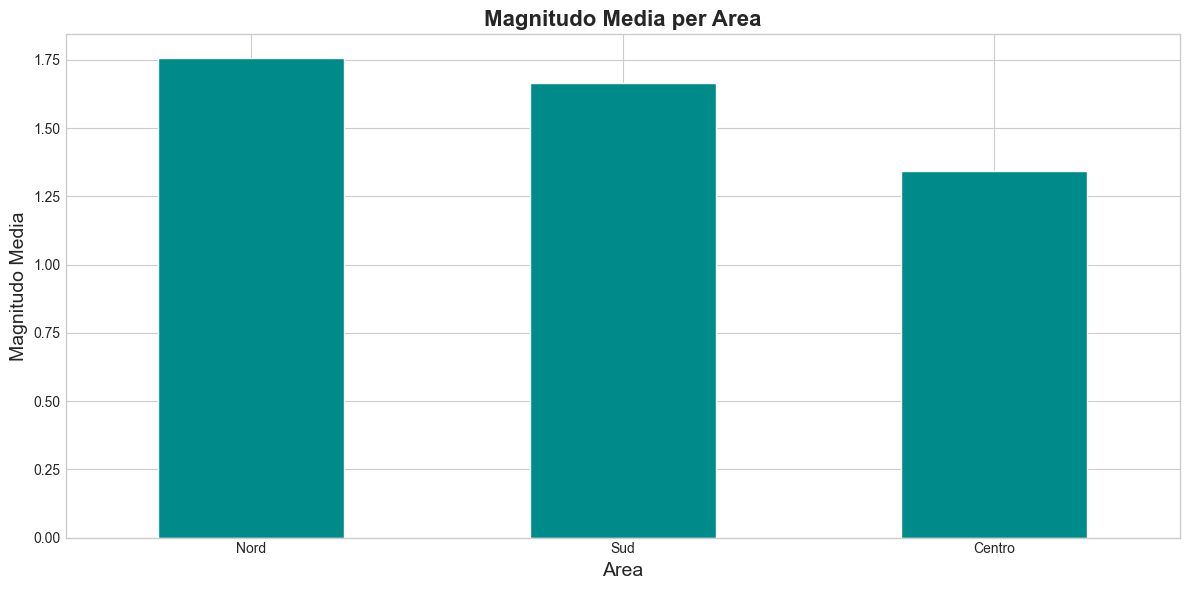

In [36]:
# Imposta lo stile dei grafici con tema seaborn bianco con griglia
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una figura di dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette di colori "muted" per Seaborn
sns.set_palette("muted")

# Calcola la magnitudo media raggruppata per 'area'
mean_magnitude = data.groupby('area')['magnitude'].mean()

# Ordina le magnitudo medie in ordine decrescente
mean_magnitude = mean_magnitude.sort_values(ascending=False)

# Crea un grafico a barre con le magnitudo medie ordinate, colore darkcyan
mean_magnitude.plot(kind='bar', color='darkcyan')

# Imposta titolo e etichette degli assi con font e dimensioni personalizzate
plt.title('Magnitudo Media per Area', fontsize=16, fontweight='bold')
plt.xlabel('Area', fontsize=14)
plt.ylabel('Magnitudo Media', fontsize=14)

# Imposta le etichette dell'asse x senza rotazione
plt.xticks(rotation=0)

# Ottimizza il layout per evitare tagli nei margini
plt.tight_layout()

# Salva il grafico in alta risoluzione nella cartella ../images con nome specificato
plt.savefig('../images/magnitudo_media_per_area.png', dpi=300, bbox_inches='tight')

# Mostra il grafico a video
plt.show()

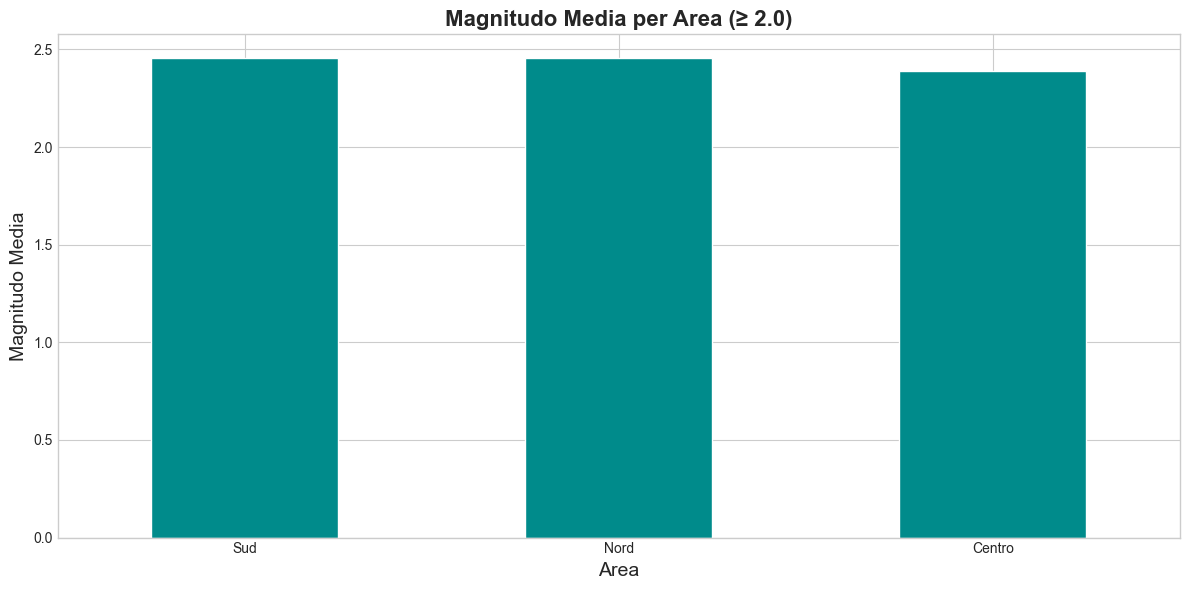

In [37]:
# Imposta lo stile del grafico con tema seaborn bianco e griglia
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una figura con dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette di colori "muted" per i plot di Seaborn
sns.set_palette("muted")

# Filtra i dati per considerare solo terremoti con magnitudo maggiore o uguale a 2.0
filtered_data = data[data['magnitude'] >= 2.0]

# Calcola la magnitudo media raggruppata per 'area' sui dati filtrati
mean_magnitude = filtered_data.groupby('area')['magnitude'].mean()

# Ordina i valori di magnitudo media in ordine decrescente
mean_magnitude = mean_magnitude.sort_values(ascending=False)

# Crea un grafico a barre per la magnitudo media ordinata, colore darkcyan
mean_magnitude.plot(kind='bar', color='darkcyan')

# Imposta titolo e etichette degli assi con dimensioni e peso del font personalizzati
plt.title('Magnitudo Media per Area (≥ 2.0)', fontsize=16, fontweight='bold')
plt.xlabel('Area', fontsize=14)
plt.ylabel('Magnitudo Media', fontsize=14)

# Ruota le etichette dell’asse x a 0 gradi (orizzontali)
plt.xticks(rotation=0)

# Ottimizza il layout per evitare che gli elementi del grafico vengano tagliati
plt.tight_layout()

# Mostra il grafico
plt.show()

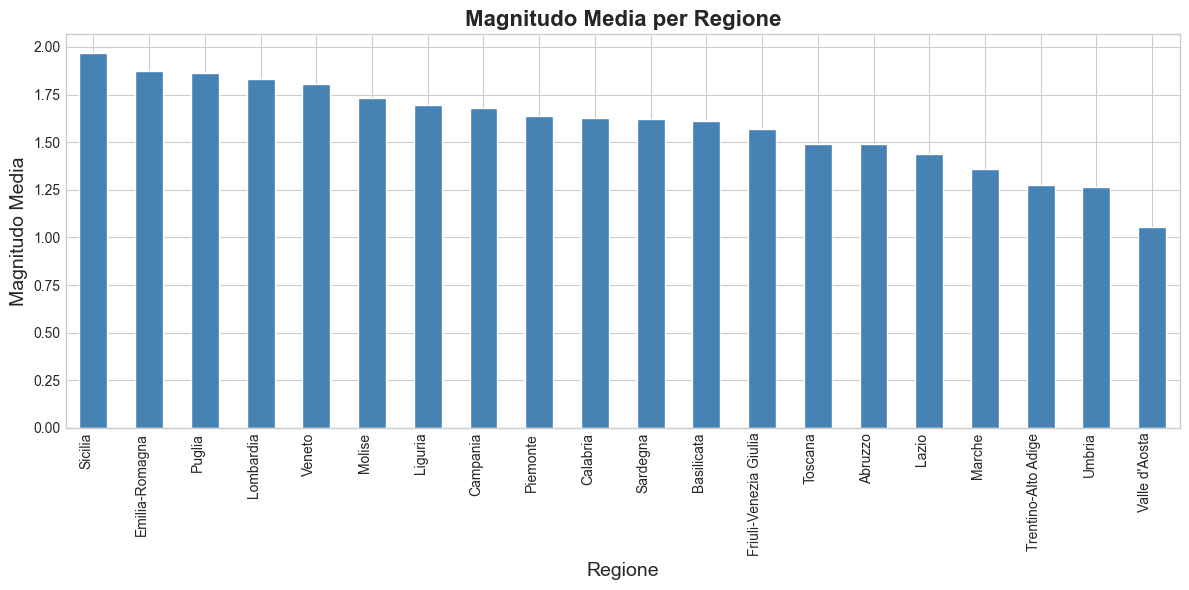

In [38]:
# Imposta lo stile del grafico con tema seaborn bianco e griglia
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una figura di dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette di colori "muted" per i plot di Seaborn
sns.set_palette("muted")

# Calcola la magnitudo media per ogni regione e ordina i risultati in ordine decrescente
order = data.groupby('region')['magnitude'].mean().sort_values(ascending=False).index

# Riorganizza i dati della magnitudo media per regione secondo l'ordine calcolato
mean_magnitude_region = data.groupby('region')['magnitude'].mean().reindex(order)

# Crea un grafico a barre con la magnitudo media per regione, usando il colore steelblue
mean_magnitude_region.plot(kind='bar', color='steelblue')

# Imposta titolo e etichette degli assi con font personalizzati
plt.title('Magnitudo Media per Regione', fontsize=16, fontweight='bold')
plt.xlabel('Regione', fontsize=14)
plt.ylabel('Magnitudo Media', fontsize=14)

# Ruota le etichette sull'asse x di 90 gradi e le allinea a destra per migliorare la leggibilità
plt.xticks(rotation=90, ha='right')

# Ottimizza il layout per evitare sovrapposizioni o tagli
plt.tight_layout()

# Mostra il grafico
plt.show()

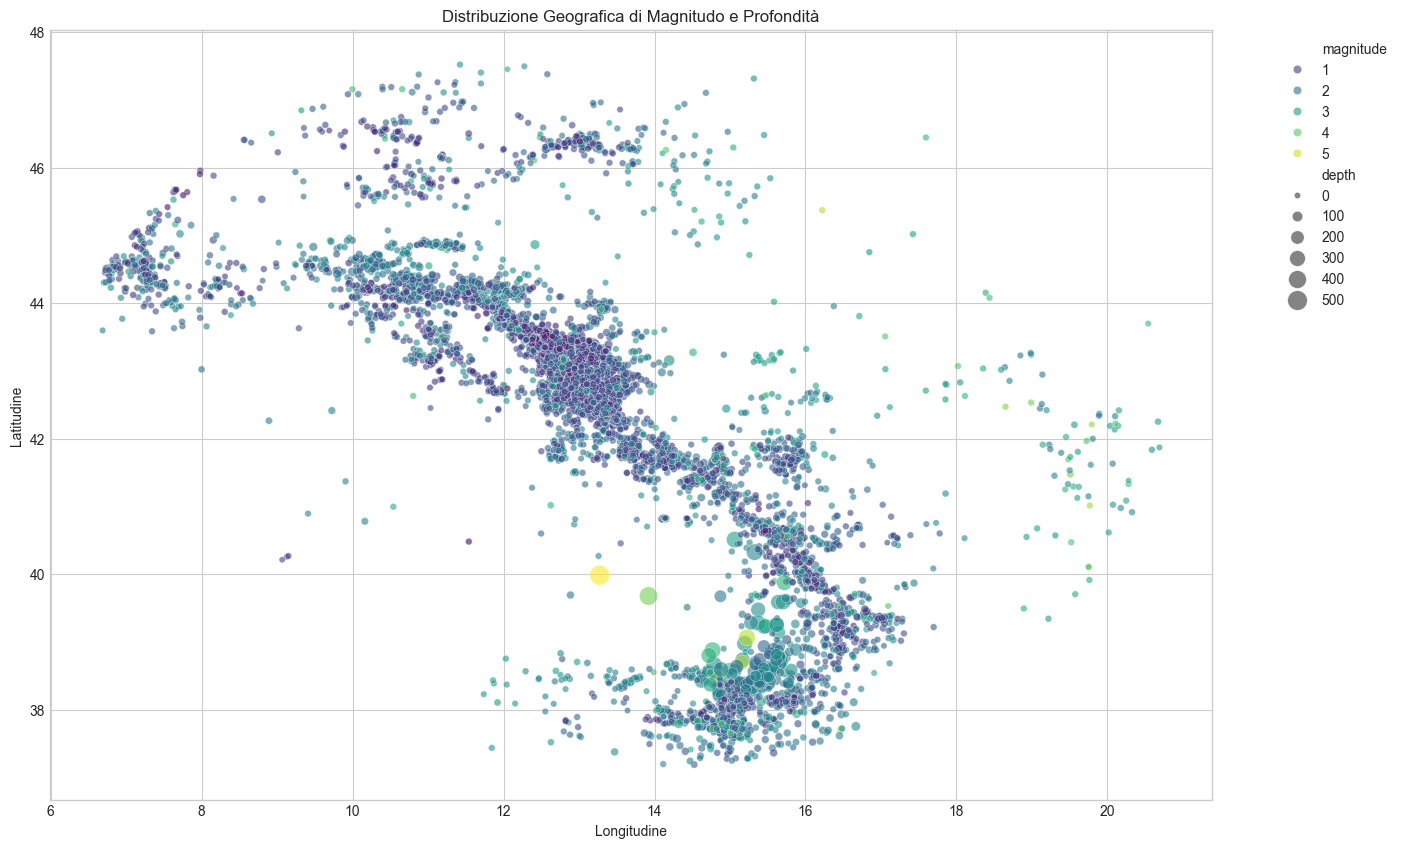

In [39]:
# Crea una figura di dimensioni 15x10 pollici
plt.figure(figsize=(15,10))

# Crea un grafico scatter con Seaborn:
# - asse X: longitudine
# - asse Y: latitudine
# - colore (hue): rappresenta la magnitudo, con una palette 'viridis' che sfuma dal blu al giallo
# - dimensione dei punti (size): rappresenta la profondità, con dimensioni variabili tra 20 e 200
# - trasparenza (alpha): 0.6 per rendere visibili i sovrapposti
# - campione casuale di 15000 eventi per gestire la densità dei dati
scatter = sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='magnitude',
    size='depth',
    sizes=(20, 200),
    alpha=0.6,
    palette='viridis',
    data=data.sample(15000)
)

# Imposta titolo e etichette degli assi
plt.title('Distribuzione Geografica di Magnitudo e Profondità')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')

# Aggiunge griglia per facilitare la lettura
plt.grid(True)

# Posiziona la legenda all'esterno a destra, in alto
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Mostra il grafico
plt.show()

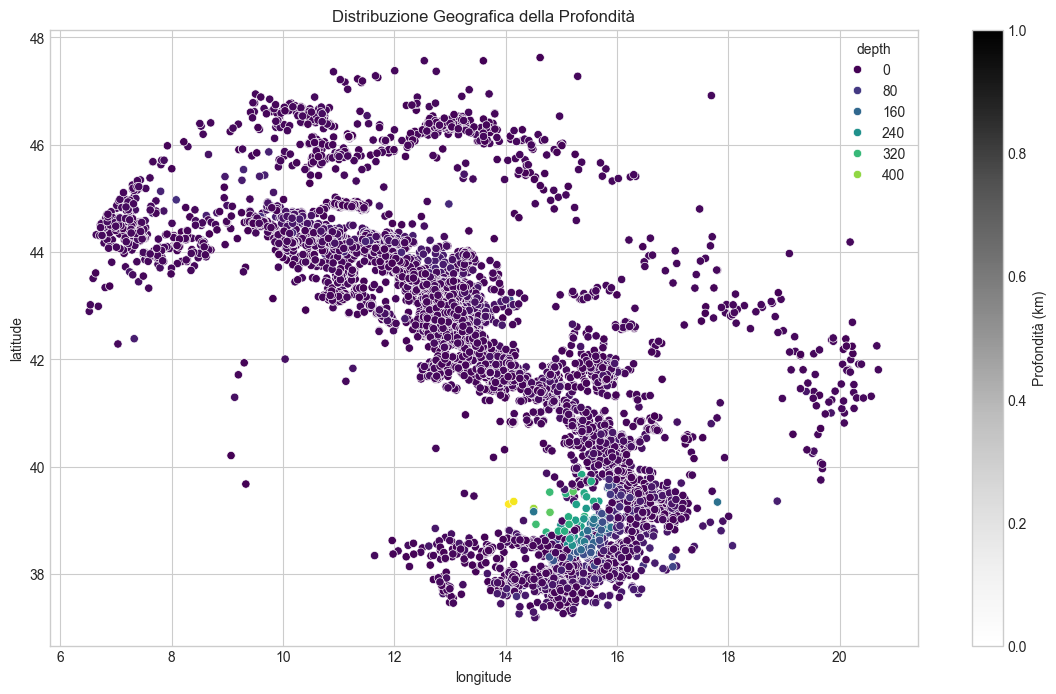

In [40]:
# Imposta la dimensione della figura a 14x8 pollici
plt.figure(figsize=(14,8))

# Crea un scatter plot con Seaborn
# - asse X: longitudine
# - asse Y: latitudine
# - colore (hue): rappresenta la profondità degli eventi
# - palette: 'viridis' per una scala di colori che va dal viola/blu al giallo
# - dati: campione casuale di 20.000 eventi (seed fisso per riproducibilità)
scatter = sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='depth',  
    palette='viridis', 
    data=data.sample(20000, random_state=42)
)

# Titolo del grafico
plt.title('Distribuzione Geografica della Profondità')

# Aggiunge una barra colore che indica la scala della profondità
plt.colorbar(scatter.collections[0], label='Profondità (km)')

# Mostra il grafico
plt.show()

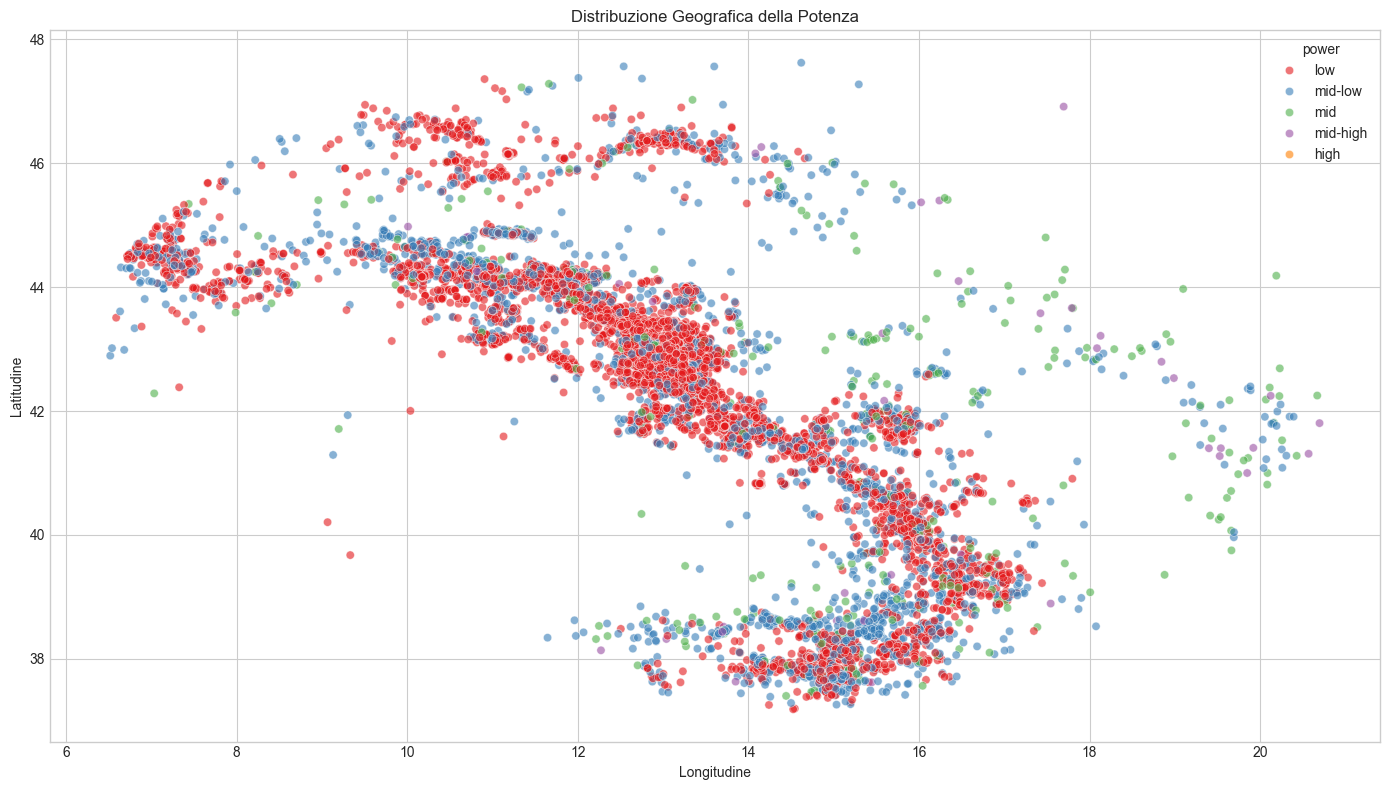

In [41]:
# Imposta la dimensione della figura a 14x8 pollici
plt.figure(figsize=(14, 8))

# Crea un grafico scatter con Seaborn
# - asse X: longitudine
# - asse Y: latitudine
# - colore (hue): categorizza i punti in base alla colonna 'power' (potenza)
# - palette: 'Set1', una palette colorata adatta per categorie distinte
# - dati: campione casuale di 20.000 eventi con random_state per riproducibilità
# - alpha: trasparenza dei punti, 0.6 per rendere visibili eventuali sovrapposizioni
scatter = sns.scatterplot(
    x='longitude',
    y='latitude',
    hue='power',
    palette='Set1',
    data=data.sample(20000, random_state=42),
    alpha=0.6
)

# Titolo e etichette degli assi
plt.title('Distribuzione Geografica della Potenza')
plt.xlabel('Longitudine')
plt.ylabel('Latitudine')

# Ottimizza il layout per evitare sovrapposizioni
plt.tight_layout()

# Mostra il grafico
plt.show()

#### Analisi temporale di magnitudo e profondità

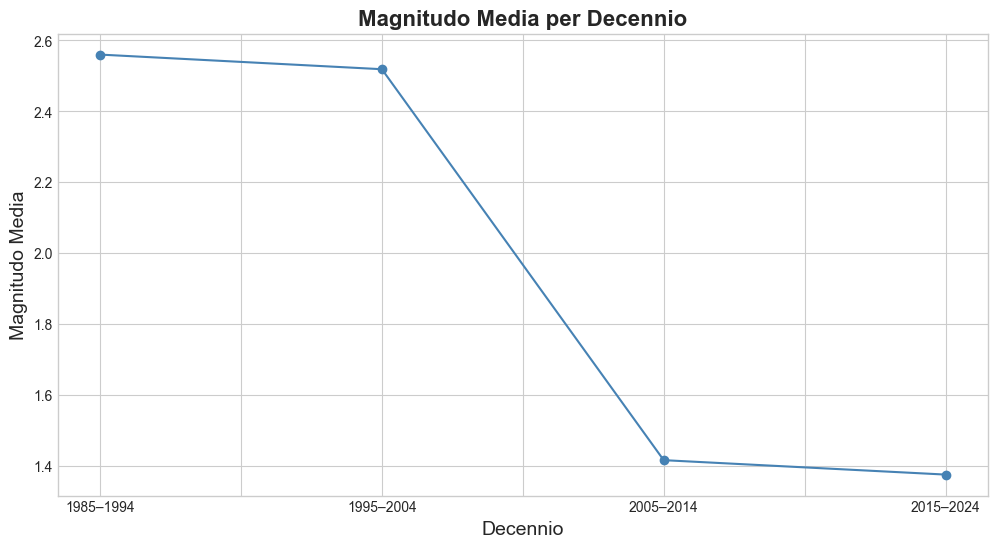

In [42]:
# Imposta lo stile del grafico utilizzando il tema "seaborn-v0_8-whitegrid"
plt.style.use('seaborn-v0_8-whitegrid')

# Crea una figura con dimensioni 12x6 pollici
plt.figure(figsize=(12, 6))

# Imposta la palette dei colori di Seaborn su "muted"
sns.set_palette("muted")

# Calcola la magnitudo media raggruppando i dati per decennio
decade_magnitude = data.groupby('decade')['magnitude'].mean()

# Traccia un grafico a linea della magnitudo media per decennio
# con marker a cerchio ('o') e colore steelblue
decade_magnitude.plot(kind='line', marker='o', color='steelblue')

# Imposta il titolo del grafico con dimensione e peso del font personalizzati
plt.title('Magnitudo Media per Decennio', fontsize=16, fontweight='bold')

# Etichetta asse x e y con font size personalizzati
plt.xlabel('Decennio', fontsize=14)
plt.ylabel('Magnitudo Media', fontsize=14)

# Ruota le etichette sull'asse x di 360° (quindi nessuna rotazione effettiva)
plt.xticks(rotation=360)

# Salva l'immagine su file con risoluzione 300 dpi e ritagliando margini bianchi inutili
plt.savefig('../images/magnitudo_media_per_decennio.png', dpi=300, bbox_inches='tight')

# Mostra il grafico a schermo
plt.show()

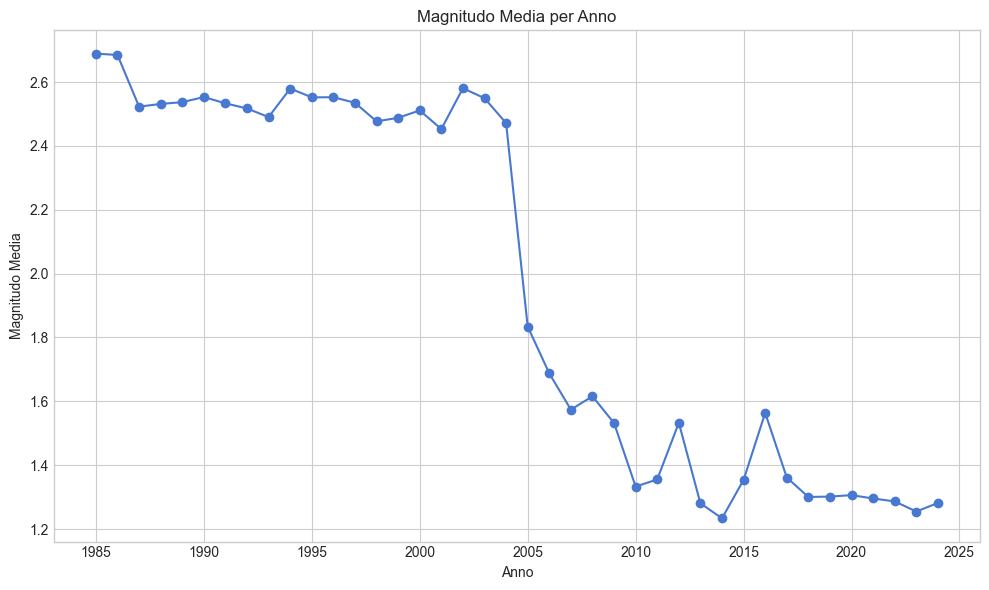

In [43]:
# Raggruppa i dati per anno calcolando la magnitudo media per ogni anno
yearly_magnitude = data.groupby('year')['magnitude'].mean()

# Crea una figura con dimensioni 10x6 pollici
plt.figure(figsize=(10, 6))

# Traccia un grafico a linee della magnitudo media annuale
# con marker a cerchio ('o') per evidenziare i punti dati
yearly_magnitude.plot(kind='line', marker='o')

# Imposta il titolo del grafico
plt.title('Magnitudo Media per Anno')

# Etichetta gli assi x e y
plt.xlabel('Anno')
plt.ylabel('Magnitudo Media')

# Abilita la griglia per facilitare la lettura dei valori
plt.grid(True)

# Applica un layout più stretto per evitare tagli di elementi
plt.tight_layout()

# Visualizza il grafico
plt.show()

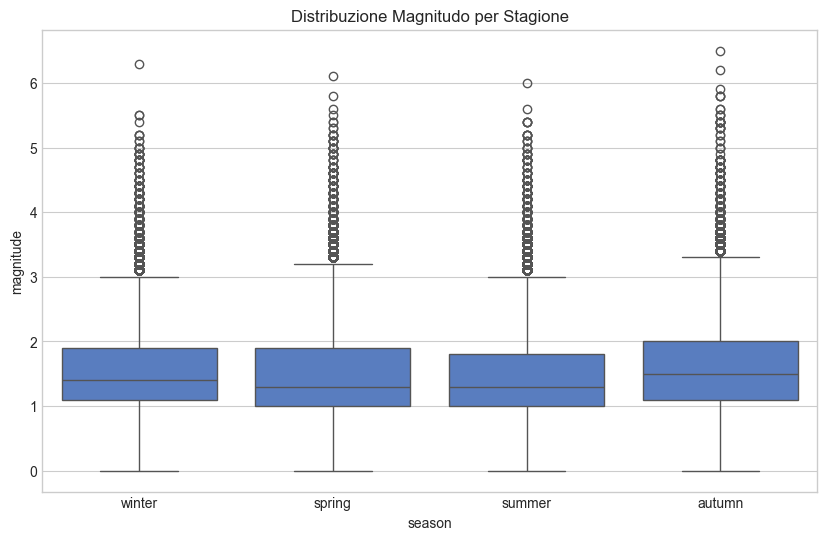

In [44]:
# Crea una figura con dimensioni 10x6 pollici
plt.figure(figsize=(10,6))

# Disegna un boxplot della magnitudo suddivisa per stagione
# 'order' specifica l'ordine stagionale desiderato: inverno, primavera, estate, autunno
sns.boxplot(x='season', y='magnitude', data=data, order=['winter','spring','summer','autumn'])

# Imposta il titolo del grafico
plt.title('Distribuzione Magnitudo per Stagione')

# Mostra il grafico
plt.show()

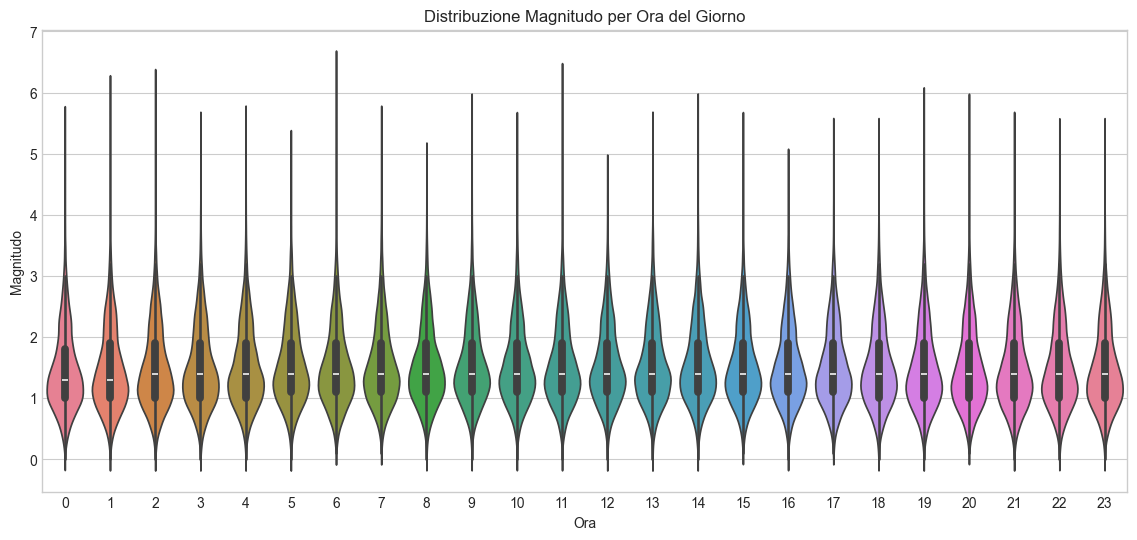

In [45]:
# Imposta la dimensione della figura a 14x6 pollici
plt.figure(figsize=(14,6))

# Disegna un violin plot della magnitudo per ogni ora del giorno
# 'x' è l'ora, 'y' la magnitudo, e 'hue' è usato per colorare ogni ora diversamente
# Il parametro 'palette' imposta una tavolozza di colori variata ('husl')
# 'legend=False' disattiva la legenda, per evitare sovraccarico visivo
sns.violinplot(x='hour', y='magnitude', hue='hour', data=data, palette='husl', legend=False)

# Titolo e etichette degli assi
plt.title('Distribuzione Magnitudo per Ora del Giorno')
plt.xlabel('Ora')
plt.ylabel('Magnitudo')

# Visualizza il grafico
plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_2524\3870801806.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='period', y='magnitude', data=data, palette={'day': '#f39c12', 'night': '#2c3e50'})


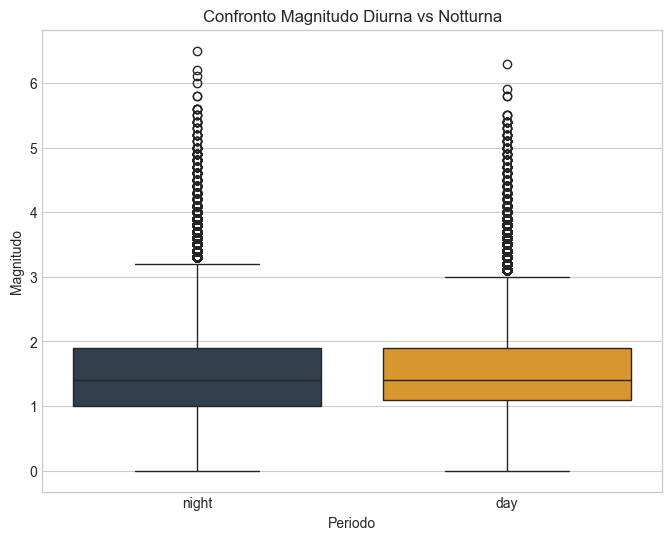

In [46]:
# Imposta la dimensione della figura a 8x6 pollici
plt.figure(figsize=(8,6))

# Crea un boxplot per confrontare la distribuzione della magnitudo tra periodi 'day' e 'night'
# L'asse x rappresenta il periodo (diurno o notturno)
# L'asse y rappresenta la magnitudo dei terremoti
# La palette specifica colori personalizzati: arancione per il giorno e blu scuro per la notte
sns.boxplot(x='period', y='magnitude', data=data, palette={'day': '#f39c12', 'night': '#2c3e50'})

# Titolo e etichette degli assi
plt.title('Confronto Magnitudo Diurna vs Notturna')
plt.xlabel('Periodo')
plt.ylabel('Magnitudo')

# Mostra il grafico
plt.show()

C:\Users\Utente\AppData\Local\Temp\ipykernel_2524\105840735.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='period', y='depth', data=data, palette={'day': '#f39c12', 'night': '#2c3e50'})


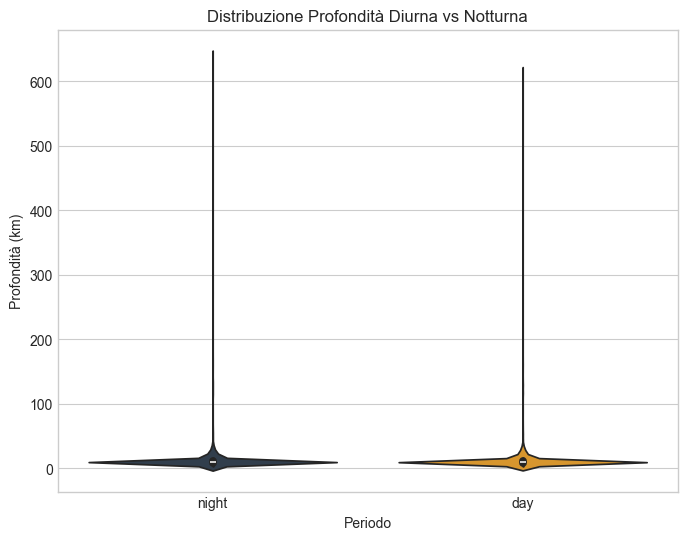

In [47]:
# Imposta la dimensione della figura a 8x6 pollici
plt.figure(figsize=(8,6))

# Crea un violin plot per confrontare la distribuzione della profondità dei terremoti
# tra periodi 'day' (diurno) e 'night' (notturno)
# L'asse x rappresenta il periodo (diurno o notturno)
# L'asse y rappresenta la profondità degli eventi sismici in km
# La palette usa colori personalizzati: arancione per il giorno e blu scuro per la notte
sns.violinplot(x='period', y='depth', data=data, palette={'day': '#f39c12', 'night': '#2c3e50'})

# Titolo e etichette degli assi
plt.title('Distribuzione Profondità Diurna vs Notturna')
plt.xlabel('Periodo')
plt.ylabel('Profondità (km)')

# Mostra il grafico
plt.show()

In [48]:
# Raggruppa i dati per la colonna 'period' (diurno/notturno)
# Calcola per ciascun gruppo:
# - la media della magnitudo ('magnitude')
# - la media della profondità ('depth')
# - il conteggio degli eventi (tramite 'hour', che conta quante righe ci sono)
night_day_comparison = data.groupby('period').agg({
    'magnitude': 'mean',
    'depth': 'mean',
    'hour': 'count'
}).rename(columns={'hour': 'count'})  # Rinominare la colonna 'hour' in 'count' per chiarezza

# Stampa i risultati
print("Confronto Notturno/Diurno:")
print(night_day_comparison)

Confronto Notturno/Diurno:
        magnitude      depth   count
period                              
day      1.533852  12.241081  209761
night    1.497554  12.651923  232061


In [49]:
from scipy import stats

# Separa i dati in due gruppi distinti:
# - magnitudo degli eventi notturni
# - magnitudo degli eventi diurni
night = data[data['period'] == 'night']['magnitude']
day = data[data['period'] == 'day']['magnitude']

# Esegue il test t di Student per campioni indipendenti
# Con nan_policy='omit' per ignorare eventuali valori NaN
t_stat, p_val = stats.ttest_ind(night, day, nan_policy='omit')

# Stampa il valore della statistica t e del p-value con formattazione
print(f"Statistica t: {t_stat:.3f}, p-value: {p_val:.4f}")

Statistica t: -18.426, p-value: 0.0000


La statistica t ci dice quanto è grande la differenza tra le due medie rispetto alla variabilità interna dei gruppi (es. quanto "rumore" c'è nei dati).

- Valore t alto: la differenza tra le medie è grande rispetto alla variabilità interna -> probabilmente significativa

- Valore t basso: la differenza tra le medie è piccola rispetto alla variabilità -> probabilmente dovuta al caso


## Analisi impatto demografico ed economico

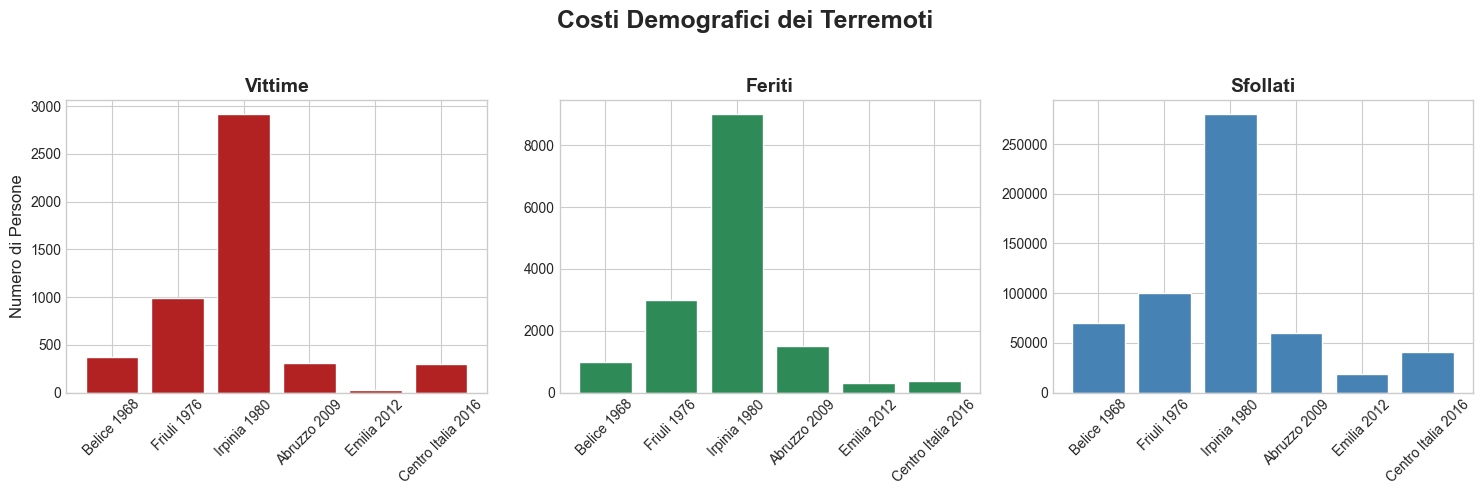

In [50]:
plt.style.use('seaborn-v0_8-whitegrid')  # Imposta lo stile grafico con griglia chiara
sns.set_palette("muted")                 # Palette colori morbida e bilanciata

# Definizione degli eventi sismici storici con relativi dati demografici
eventi = ['Belice 1968', 'Friuli 1976', 'Irpinia 1980', "Abruzzo 2009", 'Emilia 2012', 'Centro Italia 2016']
vittime = [370, 989, 2914, 309, 27, 299]      # Numero di vittime per ciascun evento
feriti = [1000, 3000, 9000, 1500, 300, 388]   # Numero di feriti per ciascun evento
sfollati = [70000, 100000, 280000, 60000, 19000, 41000]  # Numero di sfollati per ciascun evento

# Crea una figura con 3 subplot affiancati, dimensione 15x5 pollici
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

# Definizione dei colori per ciascun grafico a barre
colori = ['firebrick', 'seagreen', 'steelblue']

# Primo subplot: vittime
axs[0].bar(eventi, vittime, color=colori[0])
axs[0].set_title('Vittime', fontsize=14, fontweight='bold')
axs[0].set_ylabel('Numero di Persone', fontsize=12)
axs[0].tick_params(axis='x', rotation=45)   # Ruota le etichette sull'asse x per migliore leggibilità

# Secondo subplot: feriti
axs[1].bar(eventi, feriti, color=colori[1])
axs[1].set_title('Feriti', fontsize=14, fontweight='bold')
axs[1].tick_params(axis='x', rotation=45)

# Terzo subplot: sfollati
axs[2].bar(eventi, sfollati, color=colori[2])
axs[2].set_title('Sfollati', fontsize=14, fontweight='bold')
axs[2].tick_params(axis='x', rotation=45)

# Titolo generale della figura
plt.suptitle('Costi Demografici dei Terremoti', fontsize=18, fontweight='bold')

# Salva l'immagine su file con alta risoluzione e margini ottimizzati
plt.savefig('../images/costi_demografici_terremoti.png', dpi=300, bbox_inches='tight')

# Migliora il layout per evitare sovrapposizioni e lascia spazio per il titolo
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

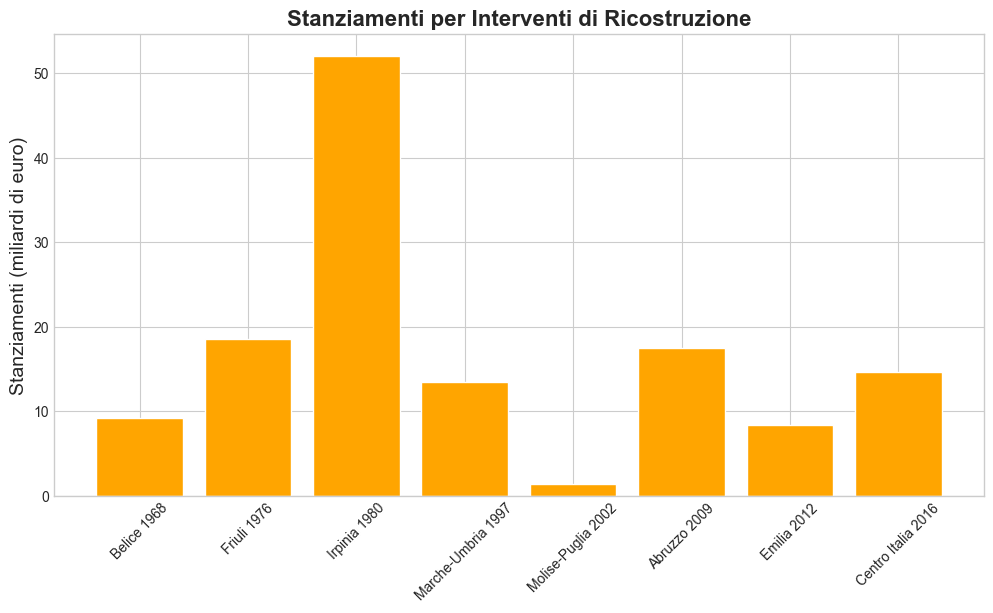

In [51]:
data = {
    'Evento': ['Belice 1968', 'Friuli 1976', 'Irpinia 1980', 'Marche-Umbria 1997', 
               'Molise-Puglia 2002', 'Abruzzo 2009', 'Emilia 2012', 'Centro Italia 2016'],
    'Stanziamenti': [9.179, 18.540, 52.026, 13.463, 1.400, 17.476, 8.406, 14.698]
}
df = pd.DataFrame(data)  # Creazione di un DataFrame pandas dai dati forniti

plt.style.use('seaborn-v0_8-whitegrid')  # Applicazione dello stile grafico con griglia chiara
sns.set_palette("muted")                  # Palette colori morbida e bilanciata (anche se non usata direttamente nel bar plot)

plt.figure(figsize=(12, 6))               # Imposta dimensione della figura (larghezza x altezza)
plt.bar(df['Evento'], df['Stanziamenti'], color='orange')  # Grafico a barre con eventi sull’asse x e stanziamenti sull’asse y

plt.title('Stanziamenti per Interventi di Ricostruzione', fontsize=16, fontweight='bold')  # Titolo con formato personalizzato
plt.ylabel('Stanziamenti (miliardi di euro)', fontsize=14)  # Etichetta asse y, esplicita l’unità di misura
plt.xticks(rotation=45)                    # Ruota le etichette degli eventi per migliorarne la leggibilità

plt.savefig('../images/stanziamenti_eventi_ricostruzione.png', dpi=300, bbox_inches='tight')  # Salvataggio dell’immagine con alta risoluzione e margini ottimizzati
plt.show()                                # Visualizza il grafico

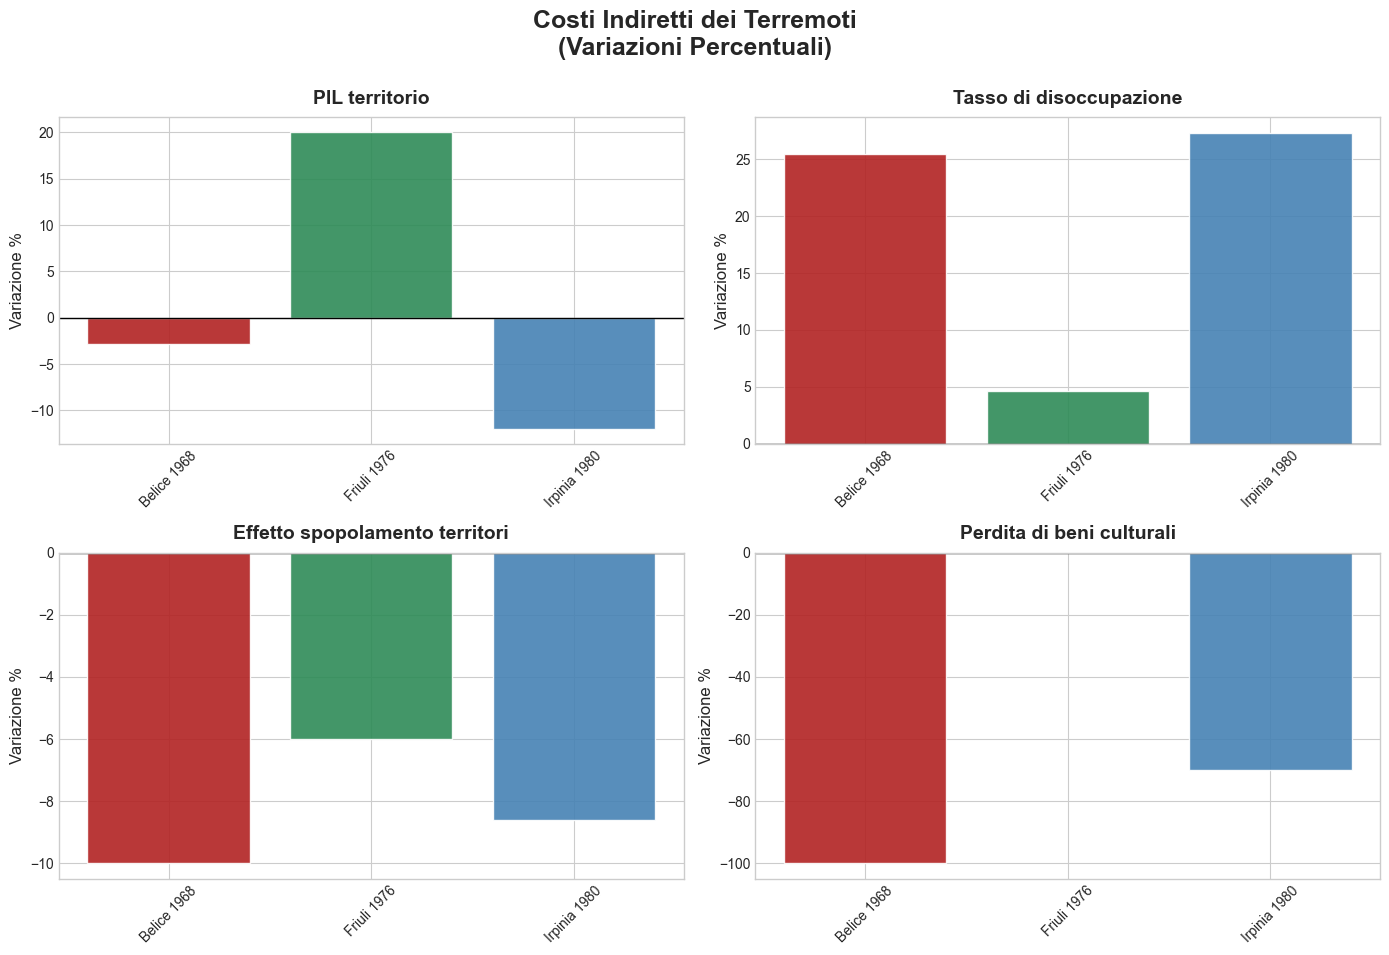

In [52]:
data = {
    'Belice 1968': [-2.80, 25.50, -10, -100],
    'Friuli 1976': [20, 4.60, -6, np.nan],
    'Irpinia 1980': [-12, 27.30, -8.60, -70]
}

categories = ['PIL territorio', 'Tasso di disoccupazione', 
              'Effetto spopolamento territori', 'Perdita di beni culturali']

df = pd.DataFrame(data, index=categories)  # DataFrame con righe come categorie e colonne come eventi

plt.style.use('seaborn-v0_8-whitegrid')    # Stile grafico con griglia chiara
sns.set_palette("muted")                    # Palette colori soft

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Creazione di una figura con 4 sottotrame (2x2)
fig.suptitle('Costi Indiretti dei Terremoti\n(Variazioni Percentuali)', 
             fontsize=18, fontweight='bold', y=0.95)  # Titolo generale con un po' di spazio sopra

colori = ['firebrick', 'seagreen', 'steelblue']  # Colori distinti per ogni terremoto
terremoti = ['Belice 1968', 'Friuli 1976', 'Irpinia 1980']

axes_flat = axes.flatten()  # Appiattisce la matrice di assi per iterare facilmente

for i, category in enumerate(categories):
    ax = axes_flat[i]
    
    # Prendo i valori della categoria corrente per ciascun terremoto
    valori = [df.loc[category, terremoto] for terremoto in terremoti]
    
    # Creo un grafico a barre verticale con i colori associati ai terremoti
    ax.bar(terremoti, valori, color=colori, alpha=0.9)
    
    ax.set_title(category, fontsize=14, fontweight='bold', pad=10)  # Titolo di ogni subplot
    ax.set_ylabel('Variazione %', fontsize=12)                      # Etichetta asse y
    ax.axhline(y=0, color='black', linewidth=1)                     # Linea orizzontale a zero per evidenziare segno positivo/negativo
    ax.tick_params(axis='x', rotation=45)                           # Ruota etichette asse x per leggibilità

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Layout compatto lasciando spazio per il titolo generale
plt.savefig('../images/costi_indiretti_terremoti.png', dpi=300, bbox_inches='tight')  # Salvataggio immagine in alta qualità
plt.show()  # Visualizza il grafico